# Predicción de tiro de baloncesto con IMUs


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [42]:
import os
import pandas as pd
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import warnings
import os
import pandas as pd
from glob import glob
warnings.filterwarnings("ignore")

path_base = "/content/drive/MyDrive/Inercial"
data_path = "/content/drive/MyDrive/Inercial/data_inercial"
test_path = "/content/drive/MyDrive/Inercial/test"
data_csv_path = "/content/drive/MyDrive/Inercial/data.csv"
data_clean = "/content/drive/MyDrive/data_clean"     # preprocesados

---

# 01 Recolección de datos

    Captura sincronizada con 3 IMUs (mano, antebrazo y brazo superior) para 10 lanzamientos y etiquetar el éxito o fallo del tiro.

    Calibrar los sensores al iniciar cada tiro respecto a una posición anatómica antes de cada ejecución.

## 1. Diseño Experimental

### 1.1 Captura de datos

Se realizó captura sincronizada utilizando **3 IMUs corporales** colocadas en:

- **Mano**
- **Antebrazo**
- **Brazo superior (bíceps)**

Cada participante ejecutó:

- **10 lanzamientos o más**
- Cada lanzamiento fue etiquetado como:
  - `0` = Falla
  - `1` = Encesta
  - `2` = Encesta Limpia


El objetivo es clasificar el resultado del tiro a partir de señales inerciales.

---

## 2. Configuración de Sensores

### 2.1 Orden e identificación de sensores

La columna `SensorId` identifica cada IMU:

| SensorId | Segmento corporal | IMU_ID |
|-----------|------------------|--------|
| 98        | Antebrazo        | 5      |
| 9F        | Bíceps           | 4      |
| 85        | Mano             | 2      |

---

## 3. Protocolo de Calibración

Antes de **cada tiro** se realizó:

1. Posición anatómica estándar (postura neutra).
2. Reinicio / referencia de orientación.
3. Registro del estado base para:
   - Compensar offset de acelerómetro.
   - Corregir drift del giroscopio.
   - Normalizar orientación inicial.

La calibración se ejecuta por lanzamiento para minimizar acumulación de error.

---

## 4. Errores

Debido a múltiples factores (fallos de Bluetooth, interferencia electromagnética y pérdida de conexión), no todos los lanzamientos registraron los tres sensores.

Se trabajará con datos faltantes, considerando válido cualquier lanzamiento que contenga al menos 1 sensor funcional.

---

## 5. Estrategia Frente a Datos Faltantes

Dado que el sistema presenta pérdidas parciales:

- Se acepta un mínimo de **1 IMU por lanzamiento**.
- Se deberá:
  - Identificar sensores disponibles por tiro.
  - Mantener consistencia temporal interna.
  - Aplicar técnicas de manejo de missing data:

El enfoque experimental no descarta muestras incompletas para evitar reducción significativa del dataset.

---

### Explorar sensores en todos los CSV

In [ ]:
# Listar archivos CSV en data_inercial
files = sorted(glob(os.path.join(data_path, "*.csv")))

print("Total archivos en data_inercial:", len(files))

Total archivos en data_inercial: 112


### Extraer sensores por archivo

In [ ]:
sensor_global_count = {}
sensor_per_file = {}

for f in files:
    df = pd.read_csv(f)

    if "SensorId" in df.columns:
        sensors = df["SensorId"].unique()
        sensor_per_file[os.path.basename(f)] = sensors

        for s in sensors:
            sensor_global_count[s] = sensor_global_count.get(s, 0) + 1

Crear DataFrame global de sensores

La columna `SensorId` identifica cada IMU:

| SensorId | Segmento corporal | IMU_ID |
|-----------|------------------|--------|
| 98        | Antebrazo        | 5      |
| 9F        | Bíceps           | 4      |
| 85        | Mano             | 2      |

Aparecen almenos 1 vez por intento

In [ ]:
sensor_global_df = pd.DataFrame.from_dict(
    sensor_global_count,
    orient="index",
    columns=["Cantidad_de_archivos"]
).sort_values("Cantidad_de_archivos", ascending=False)

print("Sensores globales:")
print(sensor_global_df)

Sensores globales:
   Cantidad_de_archivos
5                   102
2                    79
4                    27


Sensores más frecuentes en los archivos recolectados

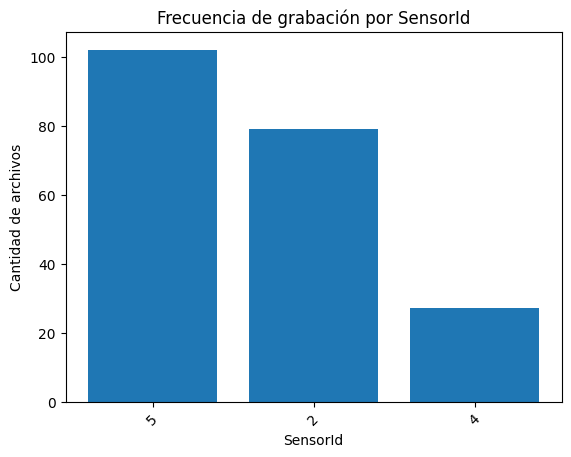

In [ ]:
plt.figure()
plt.bar(sensor_global_df.index.astype(str),
        sensor_global_df["Cantidad_de_archivos"])
plt.title("Frecuencia de grabación por SensorId")
plt.ylabel("Cantidad de archivos")
plt.xlabel("SensorId")
plt.xticks(rotation=45)
plt.show()

#### Consistencia del Sensor de Antebrazo (ID=98/5)

**Dato curioso:** El sensor del antebrazo (ID=98/5) fue el que más consistentemente grabó, con **102 de 111** lanzamientos registrados correctamente.

 Los sensores 5 (antebrazo) y 2 (mano) serán la base del modelo.

In [ ]:
import os
import pandas as pd
from glob import glob

data_info = pd.read_csv(data_csv_path)
files = glob(os.path.join(data_path, "*.csv"))

# Detectar sensores globales
all_sensors = set()

for f in files:
    df = pd.read_csv(f)
    if "SensorId" in df.columns:
        all_sensors.update(df["SensorId"].unique())

all_sensors = sorted(list(all_sensors))
print("Sensores detectados globalmente:", all_sensors)

Sensores detectados globalmente: [np.int64(2), np.int64(4), np.int64(5)]


In [ ]:
rows = []

for _, row in data_info.iterrows():

    student = row["student"]
    try_number = row["try"]
    shot_class = row["class"]
    file_name = row["name_file"]

    file_path = os.path.join(data_path, file_name)

    sensors_used = []

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        if "SensorId" in df.columns:
            sensors_used = df["SensorId"].unique().tolist()

    # Detectar sensores faltantes
    missing_sensors = list(set(all_sensors) - set(sensors_used))

    rows.append({
        "student": student,
        "try": try_number,
        "class": shot_class,
        "name_file": file_name,
        "sensores_detectados": sensors_used,
        "cantidad_sensores": len(sensors_used),
        "sensores_faltantes": missing_sensors
    })

try_sensor_df = pd.DataFrame(rows)

print(try_sensor_df.head())

  student  try  class      name_file sensores_detectados  cantidad_sensores  \
0  Mariel    1      0  Mariel_01.csv           [4, 2, 5]                  3   
1  Mariel    2      0  Mariel_02.csv           [4, 2, 5]                  3   
2  Mariel    3      1  Mariel_03.csv           [5, 4, 2]                  3   
3  Mariel    4      0  Mariel_04.csv           [4, 2, 5]                  3   
4  Mariel    5      0  Mariel_05.csv           [4, 5, 2]                  3   

  sensores_faltantes  
0                 []  
1                 []  
2                 []  
3                 []  
4                 []  


In [ ]:
incomplete_shots = try_sensor_df[try_sensor_df["cantidad_sensores"] < len(all_sensors)]

print("Tiros incompletos:")
print(incomplete_shots[["student", "try", "cantidad_sensores", "sensores_faltantes"]])

Tiros incompletos:
    student  try  cantidad_sensores sensores_faltantes
12   Mariel   13                  2                [4]
13   Mariel   14                  2                [4]
15   Mariel   16                  2                [4]
19     Eric    3                  2                [4]
21     Eric    5                  2                [4]
..      ...  ...                ...                ...
108  Norman    6                  1             [4, 5]
109  Norman    7                  1             [4, 5]
110  Norman    8                  1             [4, 5]
111  Norman    9                  1             [4, 5]
112  Norman   10                  1             [4, 5]

[87 rows x 4 columns]


In [ ]:
summary_student = try_sensor_df.groupby("student").agg({
    "cantidad_sensores": ["mean", "min", "max"],
})

print(summary_student)

        cantidad_sensores        
                     mean min max
student                          
Edgar            1.000000   1   1
Eric             2.307692   2   3
Ian              2.000000   2   2
Javier           2.500000   0   3
Juliet           1.888889   0   2
Mariel           2.823529   2   3
Norman           1.300000   1   3
Zarif            1.157895   1   2


Se identifica que se cuentaa en promedio con min información de un sensor en promedio de los intentos para cada alumno.

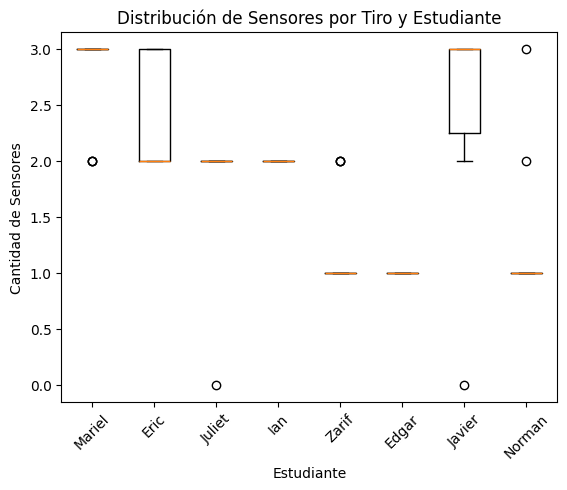

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Crear lista de listas por estudiante
data_boxplot = [
    try_sensor_df[try_sensor_df["student"] == s]["cantidad_sensores"]
    for s in try_sensor_df["student"].unique()
]

plt.boxplot(data_boxplot)
plt.xticks(range(1, len(try_sensor_df["student"].unique()) + 1),
           try_sensor_df["student"].unique(),
           rotation=45)

plt.title("Distribución de Sensores por Tiro y Estudiante")
plt.ylabel("Cantidad de Sensores")
plt.xlabel("Estudiante")
plt.show()

Se observan datos con 0 sensores, que se eliminarán por no contener información (Juliet y Javier)

In [ ]:
try_sensor_df["tiro_completo"] = try_sensor_df["cantidad_sensores"].apply(
    lambda x: 1 if x == len(all_sensors) else 0
)

complete_summary = try_sensor_df.groupby("student")["tiro_completo"].sum()

print("Tiros completos por estudiante:")
print(complete_summary)

Tiros completos por estudiante:
student
Edgar      0
Eric       4
Ian        0
Javier     7
Juliet     0
Mariel    14
Norman     1
Zarif      0
Name: tiro_completo, dtype: int64


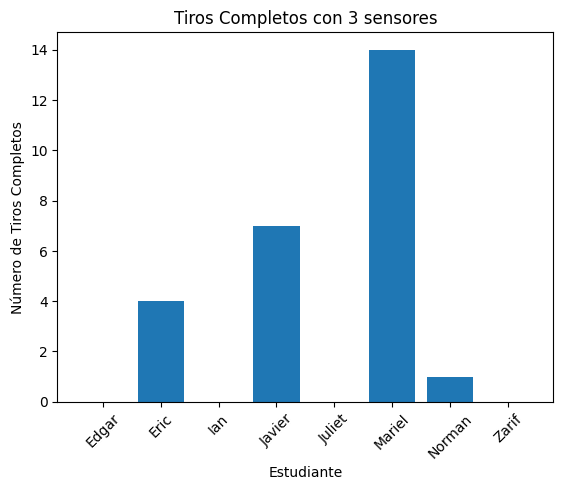

In [ ]:
plt.figure()

plt.bar(complete_summary.index.astype(str),
        complete_summary.values)

plt.title("Tiros Completos con 3 sensores")
plt.ylabel("Número de Tiros Completos")
plt.xlabel("Estudiante")
plt.xticks(rotation=45)
plt.show()

Cantidad de tiros en donde se grabaron con los 3 sensores, la mitad de los estudiantes no cuenta con algún tiro con información de 3 sensores.
Esto es importante para tomar desiciones en el balanceo de clases.

In [ ]:
mean_sensors = summary_student[("cantidad_sensores", "mean")]

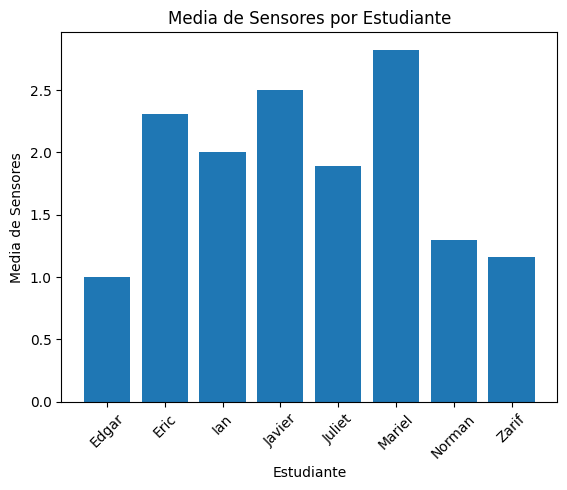

In [ ]:
plt.figure()

plt.bar(mean_sensors.index.astype(str),
        mean_sensors.values)

plt.title("Media de Sensores por Estudiante")
plt.ylabel("Media de Sensores")
plt.xlabel("Estudiante")
plt.xticks(rotation=45)
plt.show()

En promedio, todos tienen por lo menos información de 1 sensor en sus intentos registrados.

### Identificar tiros sin sensores

In [ ]:
# Filtrar tiros sin ningún sensor
no_sensor_shots = try_sensor_df[try_sensor_df["cantidad_sensores"] == 0]

print("Tiros SIN sensores grabados:")
print(no_sensor_shots[["student", "try", "class", "name_file"]])

Tiros SIN sensores grabados:
    student  try  class      name_file
34   Juliet    5      0  Juliet_05.csv
102  Javier   10      1  Javier_10.csv


In [ ]:
# Obtener lista de archivos inválidos
invalid_files = no_sensor_shots["name_file"].tolist()

# Cargar dataset original
data_info = pd.read_csv(data_csv_path)

# Filtrar dataset limpio
data_clean = data_info[~data_info["name_file"].isin(invalid_files)]

print("Dataset original:", len(data_info))
print("Dataset limpio:", len(data_clean))

Dataset original: 111
Dataset limpio: 111


In [ ]:
print("Verificación:")
print(data_clean["name_file"].isin(invalid_files).sum(), "registros inválidos restantes")

Verificación:
0 registros inválidos restantes


In [ ]:
clean_path = "/content/drive/MyDrive/Inercial/data.csv"
data_clean.to_csv(clean_path, index=False)

print("Nuevo archivo limpio guardado en:")
print(clean_path)

Nuevo archivo limpio guardado en:
/content/drive/MyDrive/Inercial/data.csv


### Como balancear

In [ ]:
# Cargar metadata original
data_info = pd.read_csv(data_csv_path)

# Detectar sensores globales reales
files = glob(os.path.join(data_path, "*.csv"))

all_sensors = set()

for f in files:
    df = pd.read_csv(f)
    if "SensorId" in df.columns:
        all_sensors.update(df["SensorId"].dropna().unique())

all_sensors = sorted(list(all_sensors))

print("Sensores detectados globalmente:", all_sensors)

Sensores detectados globalmente: [np.int64(2), np.int64(4), np.int64(5)]


In [ ]:
rows = []

for _, row in data_info.iterrows():

    student = row["student"]
    try_number = row["try"]
    shot_class = row["class"]
    file_name = row["name_file"]

    file_path = os.path.join(data_path, file_name)

    sensores = set()

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        if "SensorId" in df.columns:
            sensores.update(df["SensorId"].dropna().unique())

    rows.append({
        "student": student,
        "try": try_number,
        "class": shot_class,
        "success": 1 if shot_class != 0 else 0,
        "cantidad_sensores": len(sensores)
    })

rebuild_df = pd.DataFrame(rows)

In [ ]:
try_unique_df = (
    rebuild_df
    .groupby(["student", "try"])
    .agg({
        "success": "first",
        "cantidad_sensores": "max"  # max porque puede haber múltiples archivos por tiro
    })
    .reset_index()
)

print("Distribución actual:")
print(try_unique_df["cantidad_sensores"].value_counts())

Distribución actual:
cantidad_sensores
2    45
1    40
3    26
Name: count, dtype: int64


In [ ]:
data_info = pd.read_csv(clean_path)

rows = []

for _, row in data_info.iterrows():

    file_path = os.path.join(data_path, row["name_file"])
    sensores = set()

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if "SensorId" in df.columns:
            sensores.update(df["SensorId"].dropna().unique())

    rows.append({
        "student": row["student"],
        "try": row["try"],
        "success": 1 if row["class"] != 0 else 0,
        "cantidad_sensores": len(sensores)
    })

verify_df = pd.DataFrame(rows)

verify_unique = (
    verify_df
    .groupby(["student", "try"])
    .agg({
        "success": "first",
        "cantidad_sensores": "max"
    })
    .reset_index()
)

print("Distribución FINAL:")
print(verify_unique["cantidad_sensores"].value_counts())


Distribución FINAL:
cantidad_sensores
2    45
1    40
3    26
Name: count, dtype: int64


In [ ]:
grouped = (
    verify_unique
    .groupby(["cantidad_sensores", "success"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

Este es el resumen de la información del dataset, se segmentó la información por sensor individualmente sin repetición, i.e. Tiros con exclusivamente información de 1 sensor, 2 sensores, 3 sensores sin repetir para todos los intentos.



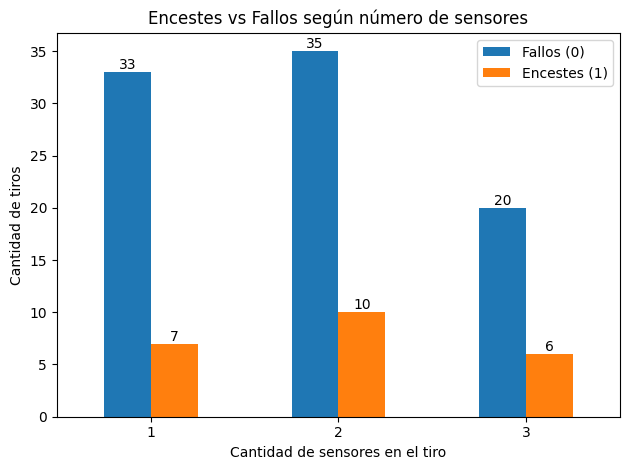

In [ ]:
ax = grouped.plot(kind="bar")

plt.xlabel("Cantidad de sensores en el tiro")
plt.ylabel("Cantidad de tiros")
plt.title("Encestes vs Fallos según número de sensores")
plt.xticks(rotation=0)
plt.legend(["Fallos (0)", "Encestes (1)"])

# Agregar valores encima de las barras
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Estrategias de Balanceo del Dataset

Se identificó un desbalance estructural tanto por clase (fallo vs enceste) como por número de sensores disponibles.

Distribución actual de la clase minoritaria (encestes):

- 1 sensor → 7
- 2 sensores → 10
- 3 sensores → 6

El límite de balance sin generación sintética lo impone la clase minoritaria:

- 1 sensor → máximo balanceable: 7 vs 7
- 2 sensores → máximo balanceable: 10 vs 10
- 3 sensores → máximo balanceable: 6 vs 6

La tasa de enceste observada es:

- 1 sensor → 17.5%
- 2 sensores → 22.2%
- 3 sensores → 23.1%

---

### Opción 1 — Undersampling

Reducir la clase mayoritaria (fallos) hasta igualar la minoritaria en cada grupo.

Ajustes necesarios:

- 1 sensor → bajar fallos de 33 a 7
- 2 sensores → bajar fallos de 35 a 10
- 3 sensores → bajar fallos de 20 a 6

Resultado final:

- 1 sensor → 7 vs 7
- 2 sensores → 10 vs 10
- 3 sensores → 6 vs 6

Ventajas:
- No se inventan datos.
- Se preserva coherencia física y biomecánica.
- Evita introducir ruido sintético.

Desventajas:
- Se pierde una cantidad considerable de información.
- Disminuye el tamaño total del dataset.
- Puede afectar la capacidad de generalización.

---

### Opción 2 — Oversampling (SMOTE o técnicas similares)

Aumentar la clase minoritaria generando muestras sintéticas dentro de cada grupo de sensores.

Ejemplo de incremento moderado:

- Generar 3 encestes adicionales en grupo 3 sensores
- Generar 3 encestes adicionales en grupo 1 sensor

Ventajas:
- No se descartan datos reales.
- Mantiene tamaño del dataset.
- Mejora la capacidad del modelo para aprender patrones minoritarios.

Desventajas:
- Puede introducir ruido artificial.
- Riesgo de generar patrones no físicamente plausibles.
- SMOTE estándar no siempre es ideal para series temporales IMU.

---

### Opción 3 — Balance Híbrido

Balance parcial

Ejemplo razonable:

#### 1 sensor
- Reducir fallos de 33 → 20  
- Aumentar encestes de 7 → 14  

Resultado: 20 vs 14 (mucho más equilibrado)

#### 2 sensores
- Reducir fallos de 35 → 22  
- Aumentar encestes de 10 → 18  

Resultado: 22 vs 18

#### 3 sensores
- Reducir fallos de 20 → 15  
- Aumentar encestes de 6 → 12  

Resultado: 15 vs 12

No es 1:1, pero ya no es 4:1.

---



## Sensores

In [ ]:
# Tomar 1 ejemplo

files = glob(os.path.join(data_path, "*.csv"))
sample_files = files[:1]

for f in sample_files:
    print("\n==============================")
    print("Archivo:", os.path.basename(f))
    df = pd.read_csv(f)
    print("Columnas:")
    print(df.columns)
    print("\nPrimeras 2 filas:")
    display(df.head(2))


Archivo: Mariel_01.csv
Columnas:
Index(['SensorId', ' TimeStamp (s)', ' FrameNumber', ' AccX (g)', ' AccY (g)',
       ' AccZ (g)', ' GyroX (deg/s)', ' GyroY (deg/s)', ' GyroZ (deg/s)',
       ' MagX (uT)', ' MagY (uT)', ' MagZ (uT)', ' EulerX (deg)',
       ' EulerY (deg)', ' EulerZ (deg)', ' QuatW', ' QuatX', ' QuatY',
       ' QuatZ', ' LinAccX (g)', ' LinAccY (g)', ' LinAccZ (g)',
       ' Pressure (kPa)', ' Altitude (m)', ' Temperature (degC)',
       ' HeaveMotion (m)'],
      dtype='object')

Primeras 2 filas:


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,4,0.00,0,0.231569,1.055345,-0.527586,118.630119,67.750877,230.197601,-34.463608,...,0.0,0.0,0.0,-0.169744,0.316244,0.084618,101.521004,-16.303003,39.259998,0.0
1,4,0.01,1,0.221655,1.130493,-0.543380,138.806961,93.046181,247.326752,-34.463608,...,0.0,0.0,0.0,-0.156804,0.242307,0.182916,101.521004,-16.303003,39.259998,0.0


Se cuenta con un csv con la información sobre la clasificación de los tiros, principalmente la clase (0,1).

In [ ]:
data_info = pd.read_csv(data_csv_path)

print("Dimensiones:", data_info.shape)
print("\nColumnas:")
print(data_info.columns)


Dimensiones: (111, 4)

Columnas:
Index(['student', 'class', 'try', 'name_file'], dtype='object')


In [ ]:
students = data_info["student"].unique()
print("Número de estudiantes:", len(students))
print("Lista estudiantes:")
print(students)

Número de estudiantes: 8
Lista estudiantes:
['Mariel' 'Eric' 'Juliet' 'Ian' 'Zarif' 'Edgar' 'Javier' 'Norman']


In [ ]:
class_counts = data_info["class"].value_counts().sort_index()
print("Distribución de clases:")
print(class_counts)

Distribución de clases:
class
0    88
1    19
2     4
Name: count, dtype: int64



Porcentaje por clase:
success
0    79.279279
1    20.720721
Name: proportion, dtype: float64


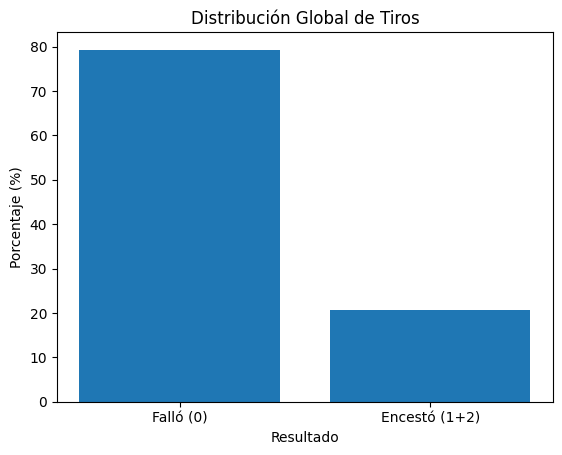

In [ ]:
# Crear variable binaria
data_info["success"] = data_info["class"].apply(lambda x: 0 if x == 0 else 1)

class_percent = data_info["success"].value_counts(normalize=True).sort_index() * 100

print("\nPorcentaje por clase:")
print(class_percent)

plt.figure()
plt.bar(["Falló (0)", "Encestó (1+2)"], class_percent.values)
plt.title("Distribución Global de Tiros")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Resultado")
plt.show()

Después de la limpieza de datos sin información de ningún sensor, se obtuvo una división de aproximadamente (class 0:80% y class 1:20%)


Estadísticas por estudiante:
         Encestes  Intentos  Porcentaje_Enceste
student                                        
Ian             4        10           40.000000
Norman          4        10           40.000000
Javier          3         9           33.333333
Eric            3        13           23.076923
Edgar           3        16           18.750000
Mariel          3        17           17.647059
Juliet          2        17           11.764706
Zarif           1        19            5.263158


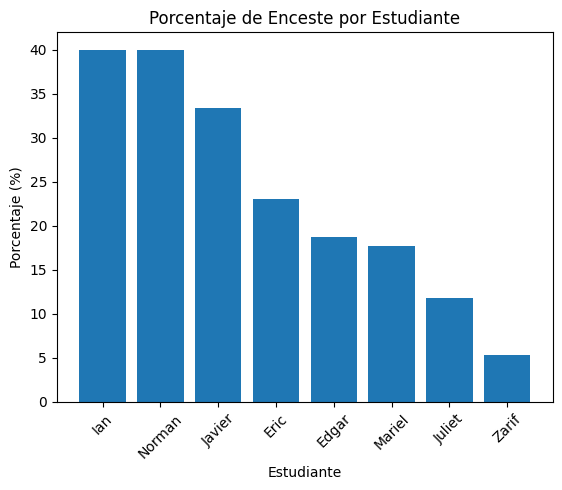

In [ ]:
# Total encestes por estudiante
student_success = data_info.groupby("student")["success"].sum()

# Total intentos por estudiante
student_total = data_info.groupby("student")["success"].count()

# Porcentaje de enceste
student_rate = (student_success / student_total) * 100

student_stats = pd.DataFrame({
    "Encestes": student_success,
    "Intentos": student_total,
    "Porcentaje_Enceste": student_rate
})

student_stats = student_stats.sort_values("Porcentaje_Enceste", ascending=False)

print("\nEstadísticas por estudiante:")
print(student_stats)

plt.figure()
plt.bar(student_stats.index.astype(str), student_stats["Porcentaje_Enceste"])
plt.xticks(rotation=45)
plt.title("Porcentaje de Enceste por Estudiante")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Estudiante")
plt.show()

Solo para ver el ranking de tiro.

In [ ]:
data_info = pd.read_csv(data_csv_path)

data_info["class"] = data_info["class"].replace(2, 1)

print("Clases después de convertir 2 → 1:")
print(data_info["class"].value_counts())

clean_path = "/content/drive/MyDrive/Inercial/data.csv"
data_info.to_csv(clean_path, index=False)

print("Dataset binario guardado en:")
print(clean_path)

Clases después de convertir 2 → 1:
class
0    88
1    23
Name: count, dtype: int64
Dataset binario guardado en:
/content/drive/MyDrive/Inercial/data.csv


Se contaba con una tercera clase (class = 2, indicaba si el tiro entró sin tocar el aro), pero solo se contaban con 4 tiros así, muy pocos para hacer aún mas una tercera categoría.

---

# 02 Procesamiento

    Analizar la implementación de filtros para eliminar ruido y segmentación para aislar el evento del tiro.

    Definición de la frecuencia de muestreo y selección estratégica de los tipos de señales disponibles, e.g., aceleración total.


## Estructura del Dataset

## Tiempo

| Columna | Tipo | Descripción |
|----------|------|-------------|
| SensorId | Categórica | Identificador del sensor (2=Mano, 5=Antebrazo, 4=Bíceps) |
| TimeStamp (s) | Continua | Tiempo en segundos |
| FrameNumber | Entero | Índice secuencial de muestra |

---

## Señales Inerciales (RAW)

| Columna | Unidad | Qué mide |
|----------|--------|----------|
| AccX, AccY, AccZ | g | Aceleración total (incluye gravedad) |
| GyroX, GyroY, GyroZ | deg/s | Velocidad angular |
| MagX, MagY, MagZ | µT | Campo magnético |

---

## Orientación

| Columna | Unidad | Descripción |
|----------|--------|------------|
| EulerX, EulerY, EulerZ | grados | Roll, Pitch, Yaw |
| QuatW, QuatX, QuatY, QuatZ | adimensional | Orientación en cuaterniones |

---

## Señales Derivadas

| Columna | Unidad | Descripción |
|----------|--------|------------|
| LinAccX, LinAccY, LinAccZ | g | Aceleración sin gravedad |
| Pressure | kPa | Presión barométrica |
| Altitude | m | Altitud estimada |
| Temperature | °C | Temperatura interna |
| HeaveMotion | m | Desplazamiento vertical estimado |

---

Observaciones:

- `TimeStamp` incrementa en pasos de 0.01 s, es una frecuencia ≈ 100 Hz.
- `GyroZ` muestra incremento progresivo a fase inicial de rotación.

El movimiento principal se detecta en aceleraciones lineales y giroscopio.

---

## Antes de preprocesamiento

,student,cantidad_sensores,class,name_file,sensor_ids
6,Edgar,1,1,Edgar_07.csv,[5]
85,Norman,1,0,Norman_04.csv,[2]
18,Eric,2,1,Erick_03.csv,"[2, 5]"
29,Ian,2,0,Ian_01.csv,"[2, 5]"
41,Javier,3,1,Javier_03.csv,"[2, 4, 5]"
65,Mariel,3,0,Mariel_01.csv,"[2, 4, 5]"


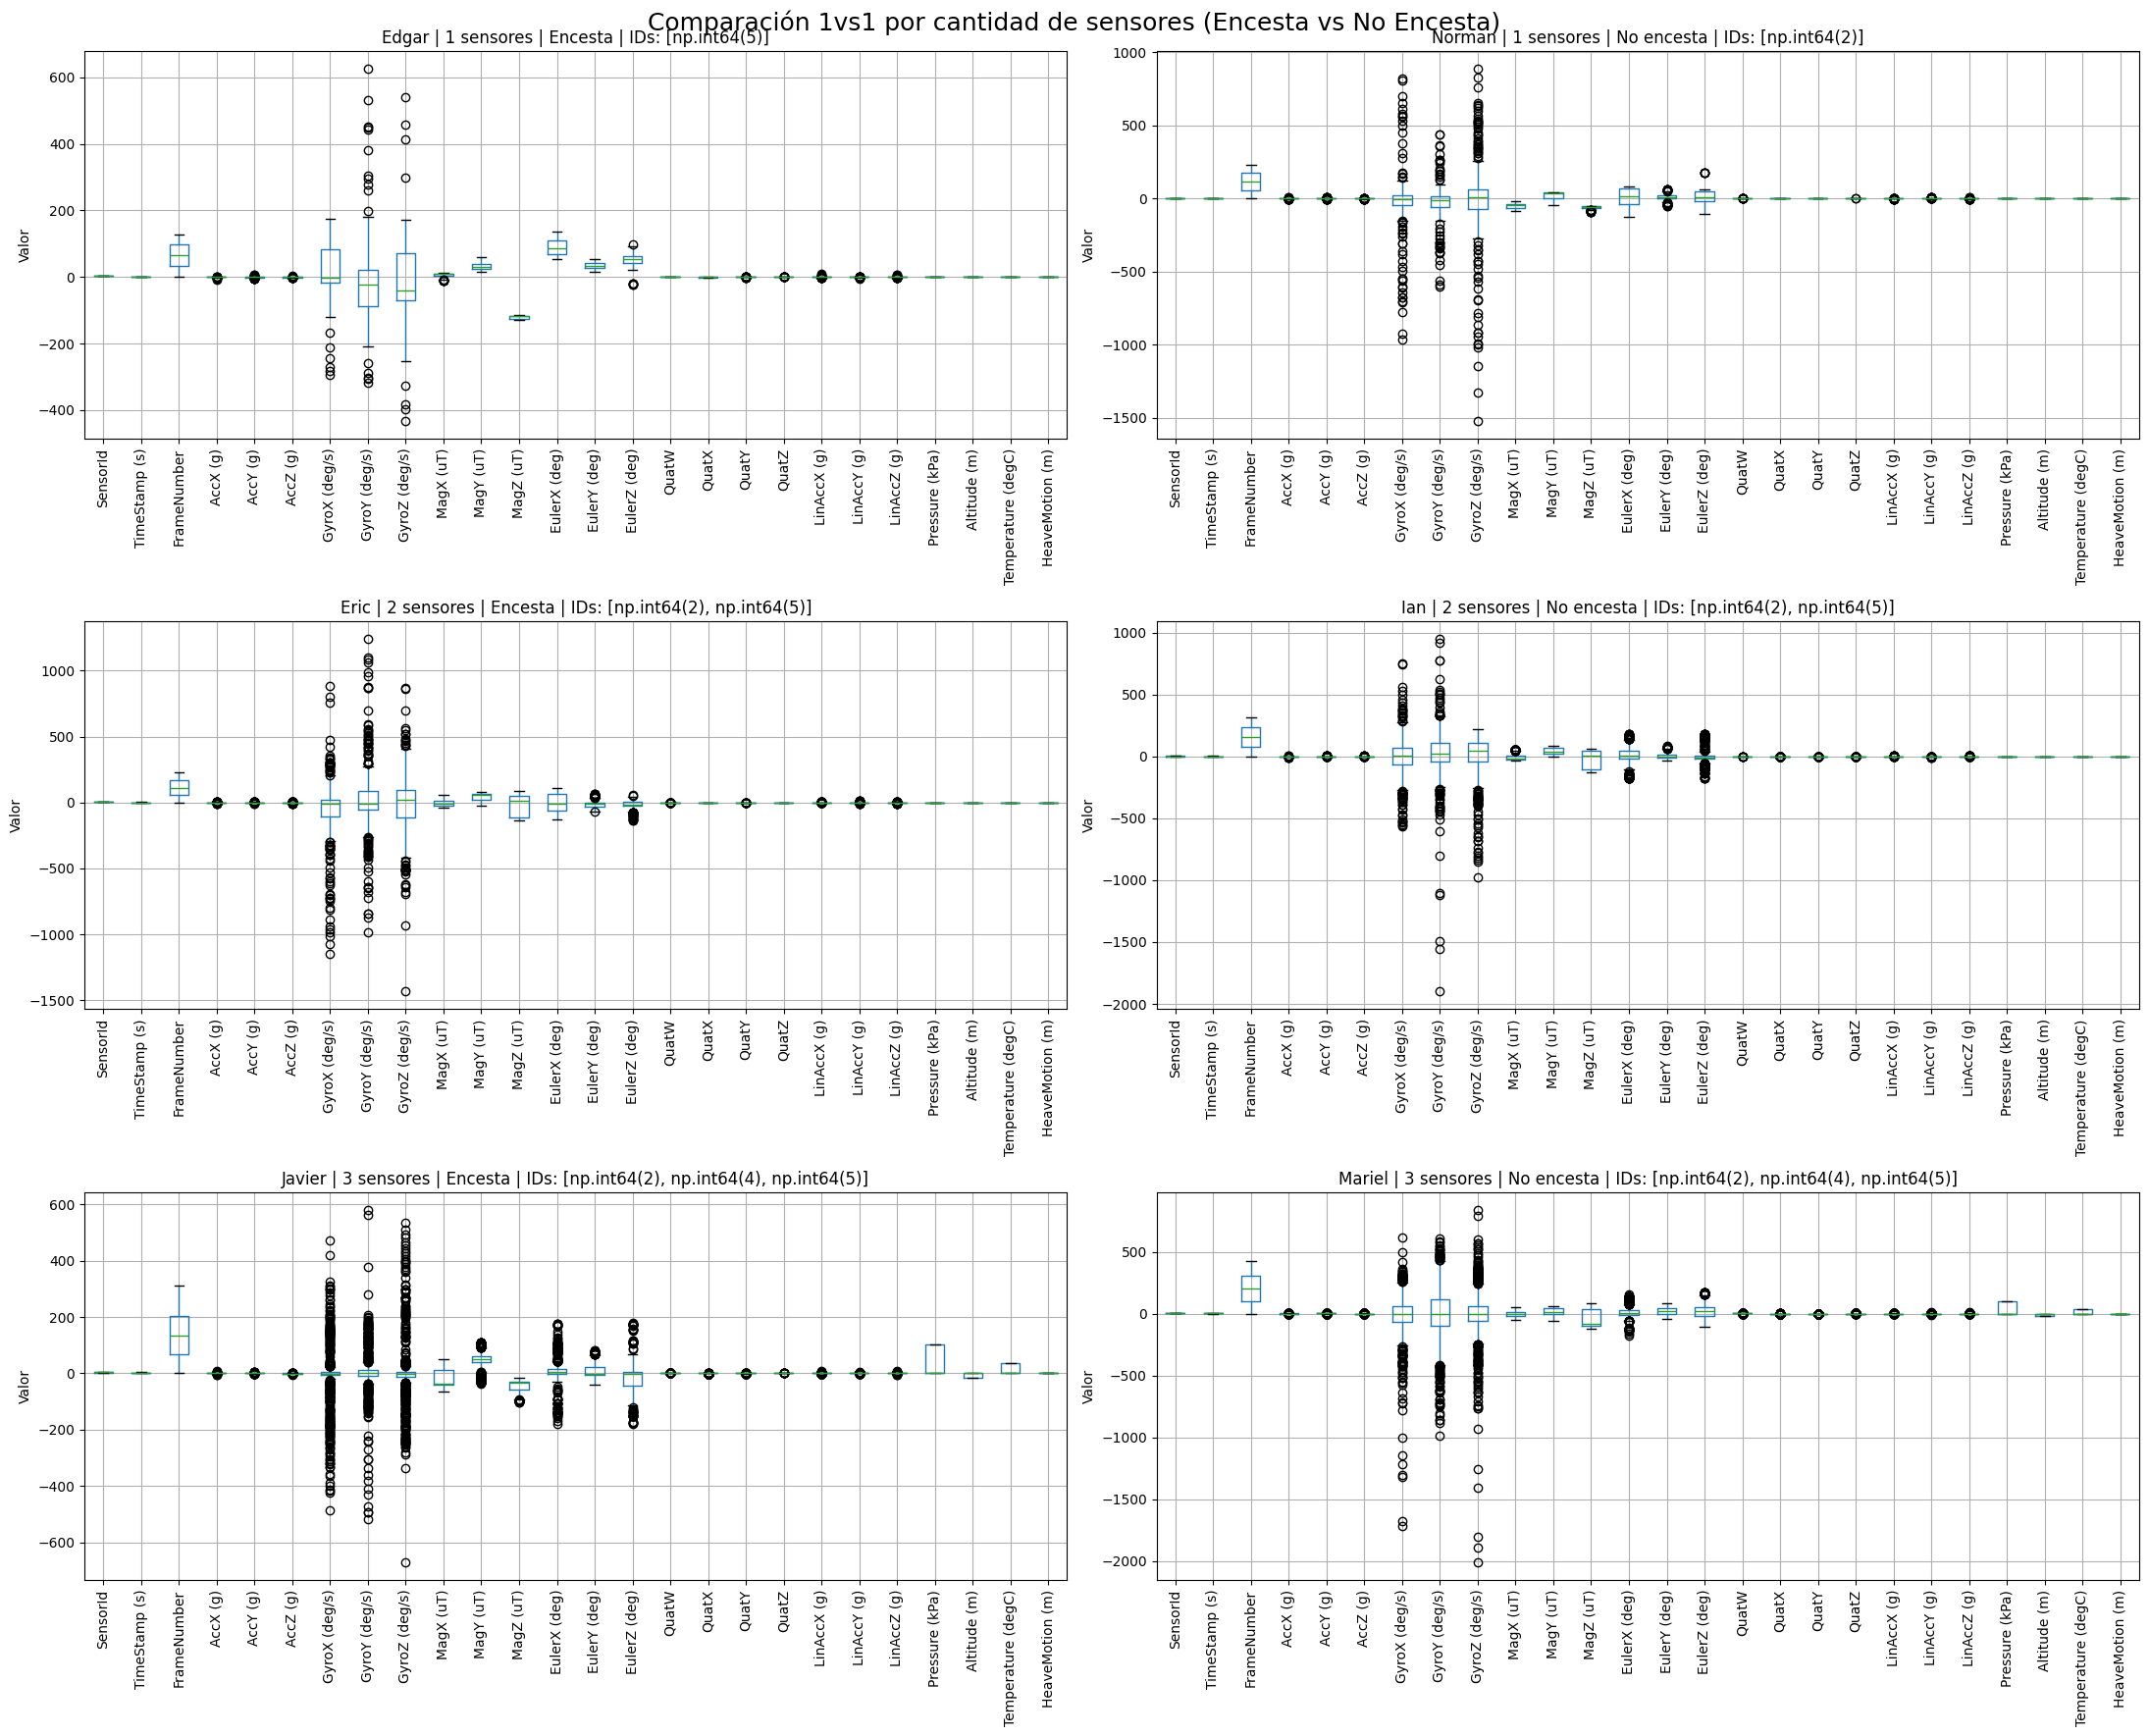

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==============================
# 1. Leer dataset con clases
# ==============================
data_info = pd.read_csv(data_csv_path)

# ==============================
# 2. Contar cantidad de sensores por tiro e identificar IDs
# ==============================
rows = []

for _, row in data_info.iterrows():
    file_path = os.path.join(data_path, row["name_file"])
    sensores = set()

    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path)
        df_temp.columns = df_temp.columns.str.strip()
        if "SensorId" in df_temp.columns:
            sensores.update(df_temp["SensorId"].dropna().unique())

    rows.append({
        "student": row["student"],
        "try": row["try"],
        "class": 1 if row["class"] > 0 else 0,  # solo 0 y 1
        "name_file": row["name_file"],
        "cantidad_sensores": len(sensores),
        "sensor_ids": list(sensores)
    })

try_df = pd.DataFrame(rows)

# Agrupar por tiro único
try_unique = (
    try_df
    .groupby(["student", "try"])
    .agg({
        "class": "first",
        "name_file": "first",
        "cantidad_sensores": "max",
        "sensor_ids": "first"
    })
    .reset_index()
)

# ==============================
# 3. Seleccionar 6 tiros: 1 vs 1 por sensores
# ==============================
selected = []
used_students = set()

for sensors in [1, 2, 3]:
    # Encesta
    enceste = try_unique[
        (try_unique["cantidad_sensores"] == sensors) &
        (try_unique["class"] == 1) &
        (~try_unique["student"].isin(used_students))
    ]
    if not enceste.empty:
        selected.append(enceste.iloc[0])
        used_students.add(enceste.iloc[0]["student"])

    # Fallo
    fallo = try_unique[
        (try_unique["cantidad_sensores"] == sensors) &
        (try_unique["class"] == 0) &
        (~try_unique["student"].isin(used_students))
    ]
    if not fallo.empty:
        selected.append(fallo.iloc[0])
        used_students.add(fallo.iloc[0]["student"])

# ==============================
# 4. Mostrar información de los seleccionados
# ==============================
selected_df = pd.DataFrame(selected)
display(selected_df[["student", "cantidad_sensores", "class", "name_file", "sensor_ids"]])

# ==============================
# 5. Graficar grid 3x2 boxplots
# ==============================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    file_path = os.path.join(data_path, row["name_file"])
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    numeric_df = df.select_dtypes(include=[np.number])

    numeric_df.boxplot(ax=ax, rot=90)

    ax.set_title(
        f'{row["student"]} | {row["cantidad_sensores"]} sensores | '
        f'{"Encesta" if row["class"]==1 else "No encesta"} | IDs: {row["sensor_ids"]}'
    )
    ax.set_ylabel("Valor")

# Apagar ejes sobrantes si faltan
for i in range(len(selected), len(axes)):
    axes[i].axis("off")

plt.suptitle("Comparación 1vs1 por cantidad de sensores (Encesta vs No Encesta)", fontsize=18)
plt.tight_layout()
plt.show()

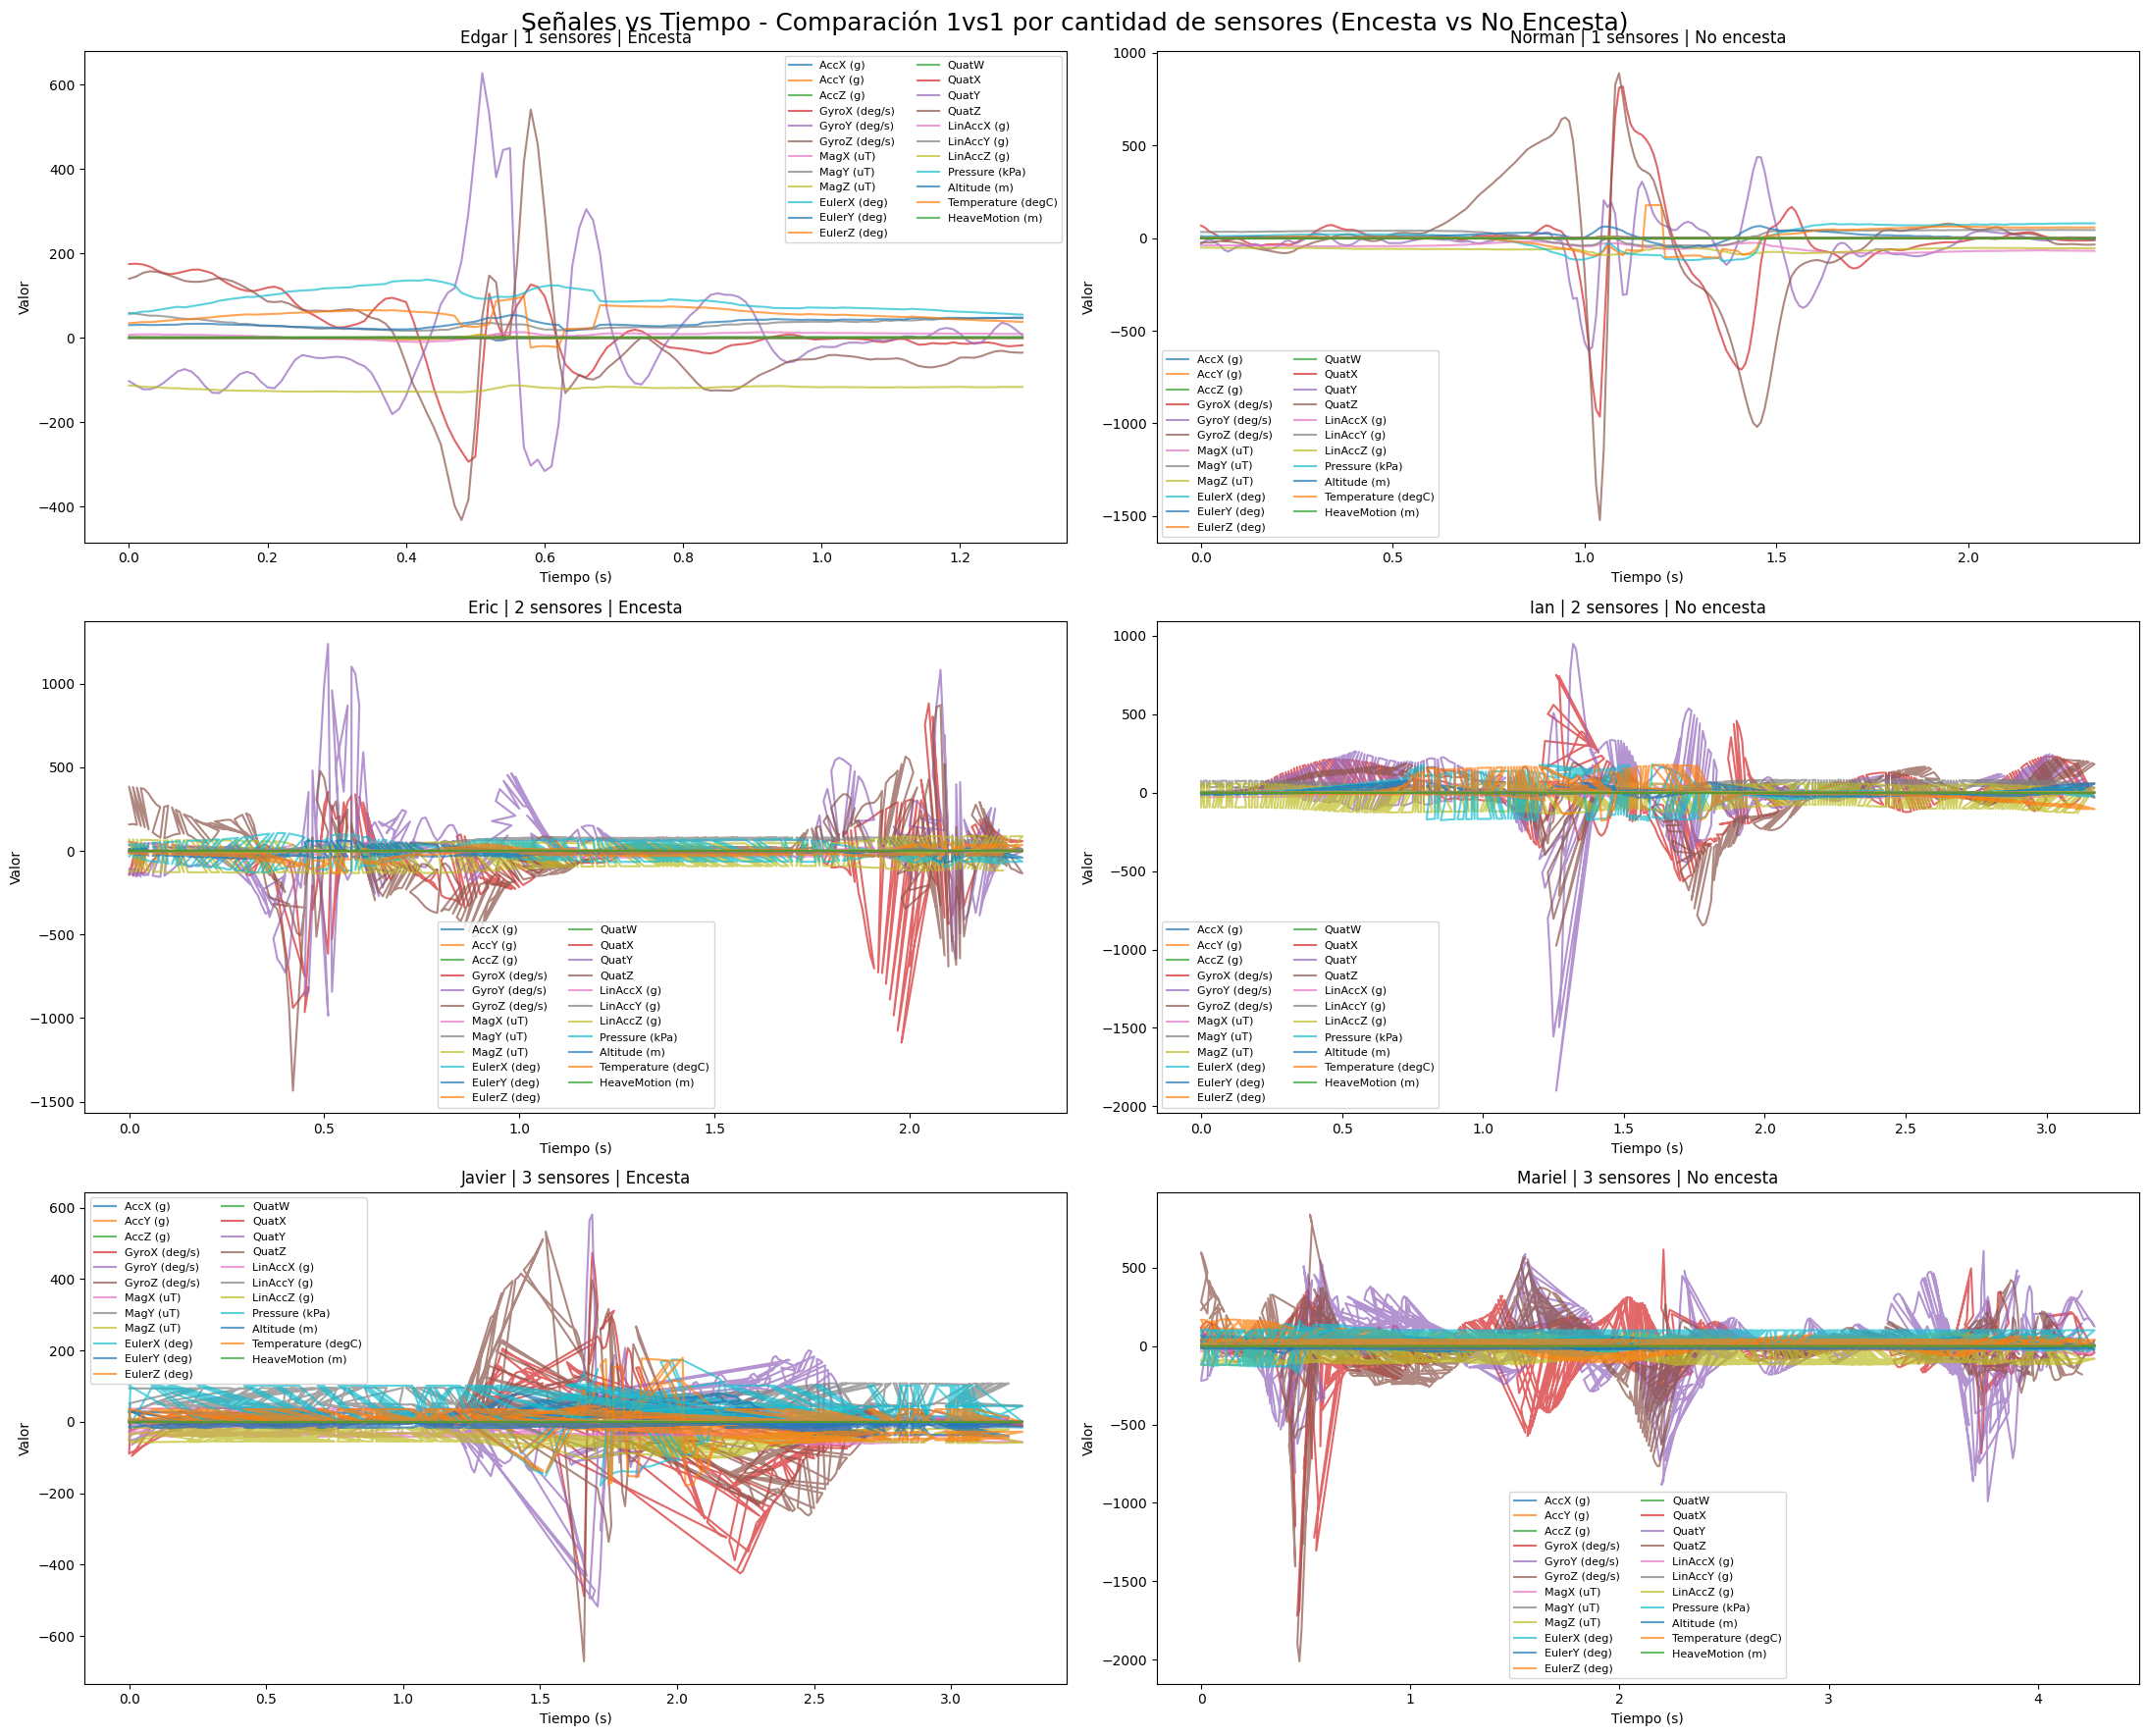

In [ ]:
# ==============================
# Graficar señales vs tiempo
# ==============================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    file_path = os.path.join(data_path, row["name_file"])
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # Seleccionar TimeStamp y columnas numéricas
    if "TimeStamp (s)" in df.columns:
        time = df["TimeStamp (s)"]
    else:
        time = df["FrameNumber"]  # fallback

    numeric_df = df.select_dtypes(include=[np.number]).copy()

    # Quitar columnas que no son señales
    for col in ["TimeStamp (s)", "FrameNumber", "SensorId"]:
        if col in numeric_df.columns:
            numeric_df = numeric_df.drop(columns=[col])

    # Graficar cada señal vs tiempo
    for col in numeric_df.columns:
        ax.plot(time, numeric_df[col], alpha=0.7, label=col)

    ax.set_title(f'{row["student"]} | {row["cantidad_sensores"]} sensores | {"Encesta" if row["class"]==1 else "No encesta"}')
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Valor")
    ax.legend(fontsize=8, ncol=2)

# Apagar ejes sobrantes si faltan
for i in range(len(selected), len(axes)):
    axes[i].axis("off")

plt.suptitle("Señales vs Tiempo - Comparación 1vs1 por cantidad de sensores (Encesta vs No Encesta)", fontsize=18)
plt.tight_layout()
plt.show()

- Al **inicio**: Hay un período largo sin movimiento (línea plana con ruido)
- Al **final**: También hay un período sin movimiento relevante
- En el **centro**: Se ven los picos correspondientes a los tiros



## Preprocesamiento

El objetivo del preprocesamiento es aislar el evento principal del lanzamiento, reducir ruido de alta frecuencia y normalizar las señales para que el modelo aprenda patrones dinámicos y no magnitudes absolutas.

---

## Limpieza de nombres de columnas

Se eliminan espacios innecesarios y unidades entre paréntesis.  
Esto garantiza consistencia en el acceso a columnas como:

- LinAccX  
- LinAccY  
- LinAccZ  

Evita errores derivados de inconsistencias en nombres exportados por el dispositivo.

---

## Magnitud de aceleración lineal

Se calcula la magnitud de la aceleración lineal sin gravedad:

La magnitud de la aceleración lineal se calcula como:

$$
||a(t)|| = \sqrt{LinAccX(t)^2 + LinAccY(t)^2 + LinAccZ(t)^2}
$$

Esta magnitud representa la intensidad total del movimiento del segmento corporal.

Se utiliza para detectar automáticamente el instante de máxima aceleración, que corresponde típicamente a la fase de liberación del balón.

---

## Reducción de ruido mediante Wavelets

Se aplica descomposición wavelet discreta usando la familia Daubechies (db4).

El procedimiento:

- Descomponer la señal en coeficientes de aproximación y detalle.
- Estimar el nivel de ruido:

$$
\sigma = \frac{\text{mediana}(|c|)}{0.6745}
$$

- Calcular umbral universal:

$$
\lambda = \sigma \sqrt{2 \log(n)}
$$

- Aplicar umbralización suave (soft thresholding).
- Reconstruir la señal.

Esto elimina ruido de alta frecuencia preservando la forma biomecánica del movimiento.

---

## Suavizado con filtro Savitzky–Golay

Se aplica un filtro polinomial local para suavizar sin distorsionar picos.

Ventajas:

- Preserva máximos locales.
- Mantiene forma de la señal.
- Reduce fluctuaciones espurias.

Se usa ventana pequeña y polinomio de orden bajo para evitar sobre–suavizado.

---

## Detección automática del evento de tiro

Se identifica el índice del pico máximo de la magnitud filtrada:

$$
t_{pico} = \arg\max \|a(t)\|
$$

Este punto representa el momento de mayor aceleración.

---

## Extracción de ventana temporal

Se recorta una ventana centrada en el pico:

$$
[t_{pico} - \Delta_1,\; t_{pico} + \Delta_2]
$$

Con frecuencia de muestreo ≈ 100 Hz y ventanas de 60 muestras antes y después, se obtiene aproximadamente 1.2 segundos de señal.

Esto encapsula:

- Preparación del lanzamiento  
- Liberación  
- Seguimiento  

Se eliminan partes irrelevantes previas o posteriores.

---

## Normalización Z-Score

Se normalizan únicamente las señales físicas (no el tiempo).

Para cada señal:

$$
x_{norm} = \frac{x - \mu}{\sigma + \epsilon}
$$

Donde: $\mu$ es la media del tiro, $\sigma$ es la desviación estándar y $\epsilon$ evita división por cero.

Esto elimina dependencia de magnitud absoluta y permite que el modelo aprenda forma y dinámica relativa.

---

Cada archivo procesado contiene:

- Ventana centrada en el evento principal
- Señales filtradas y suavizadas
- Datos normalizados por tiro
- Tiempo preservado sin transformación


In [55]:
import os
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import pywt
from tqdm import tqdm


# ==============================
# Funciones utilitarias
# ==============================
def clean_colnames(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r"\s*\(.*\)", "", regex=True)
    return df


def wavelet_denoise(signal, wavelet='db4', level=1):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = (1/0.6745) * np.median(np.abs(coeffs[-level]))
    uthresh = sigma * np.sqrt(2*np.log(len(signal)))
    coeffs[1:] = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]
    rec = pywt.waverec(coeffs, wavelet)

    if len(rec) > len(signal):
        rec = rec[:len(signal)]
    elif len(rec) < len(signal):
        rec = np.pad(rec, (0, len(signal)-len(rec)), mode='edge')

    return rec


def smooth_signal(signal, window_length=11, polyorder=2):
    if len(signal) < window_length:
        return signal
    return savgol_filter(signal, window_length=window_length, polyorder=polyorder)


def zscore_normalize(signal):
    return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)


# ==============================
# Preprocesamiento individual
# ==============================
def preprocess_shot(df, window_before=60, window_after=60):
    df = clean_colnames(df)

    linacc_cols = ['LinAccX', 'LinAccY', 'LinAccZ']

    for col in linacc_cols:
        if col not in df.columns:
            raise ValueError(f"{col} no encontrado en columnas: {df.columns}")

    df['LinAcc_mag'] = np.sqrt(
        df['LinAccX']**2 +
        df['LinAccY']**2 +
        df['LinAccZ']**2
    )

    for col in linacc_cols + ['LinAcc_mag']:
        df[col+'_filt'] = wavelet_denoise(df[col].values)
        df[col+'_filt'] = smooth_signal(df[col+'_filt'])

    peak_idx = np.argmax(df['LinAcc_mag_filt'].values)

    start_idx = max(0, peak_idx - window_before)
    end_idx = min(len(df), peak_idx + window_after)

    df_window = df.iloc[start_idx:end_idx].reset_index(drop=True)

    time_cols = [c for c in ['TimeStamp', 'TimeStamp (s)', 'FrameNumber']
                 if c in df_window.columns]

    signal_cols = df_window.select_dtypes(include=[np.number]).columns
    signal_cols = [c for c in signal_cols if c not in time_cols]

    for col in signal_cols:
        df_window[col] = zscore_normalize(df_window[col].values)

    return df_window


# ==============================
# Función principal
# ==============================
def preprocess_dataset(data_path: str,
                       clean_path: str,
                       window_before: int = 60,
                       window_after: int = 60):
    """
    Procesa todos los CSV dentro de data_path
    y guarda los CSV limpios en clean_path.
    No requiere archivo de clases.
    """

    os.makedirs(clean_path, exist_ok=True)

    files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

    for file in tqdm(sorted(files)):

        file_path = os.path.join(data_path, file)

        try:
            df_shot = pd.read_csv(file_path)
            df_clean = preprocess_shot(
                df_shot,
                window_before=window_before,
                window_after=window_after
            )

            save_file = os.path.join(clean_path, file)
            df_clean.to_csv(save_file, index=False)

        except Exception as e:
            print(f"Error en {file}: {e}")

    print("Preprocesamiento completado. Archivos guardados en:", clean_path)

In [56]:
data_path = "/content/drive/MyDrive/Inercial/data_inercial"
clean_path = "/content/drive/MyDrive/data_clean"

preprocess_dataset(
    data_path=data_path,
    clean_path=clean_path
)

100%|██████████| 111/111 [00:05<00:00, 19.19it/s]

Preprocesamiento completado. Archivos guardados en: /content/drive/MyDrive/data_clean


## Visualización con preprocesamiento

,student,cantidad_sensores,class,name_file,sensor_ids
6,Edgar,1,1,Edgar_07.csv,[0.0]
85,Norman,1,0,Norman_04.csv,[0.0]
18,Eric,2,1,Erick_03.csv,"[-0.9816498106685884, 1.0186931997504218]"
29,Ian,2,0,Ian_01.csv,"[0.9045340276726848, -1.1055415893777258]"
41,Javier,3,1,Javier_03.csv,"[-0.9951906212636888, 1.112271870824123, 0.409..."
65,Mariel,3,0,Mariel_01.csv,"[0.4777163603183043, 1.2630035279648315, -1.09..."


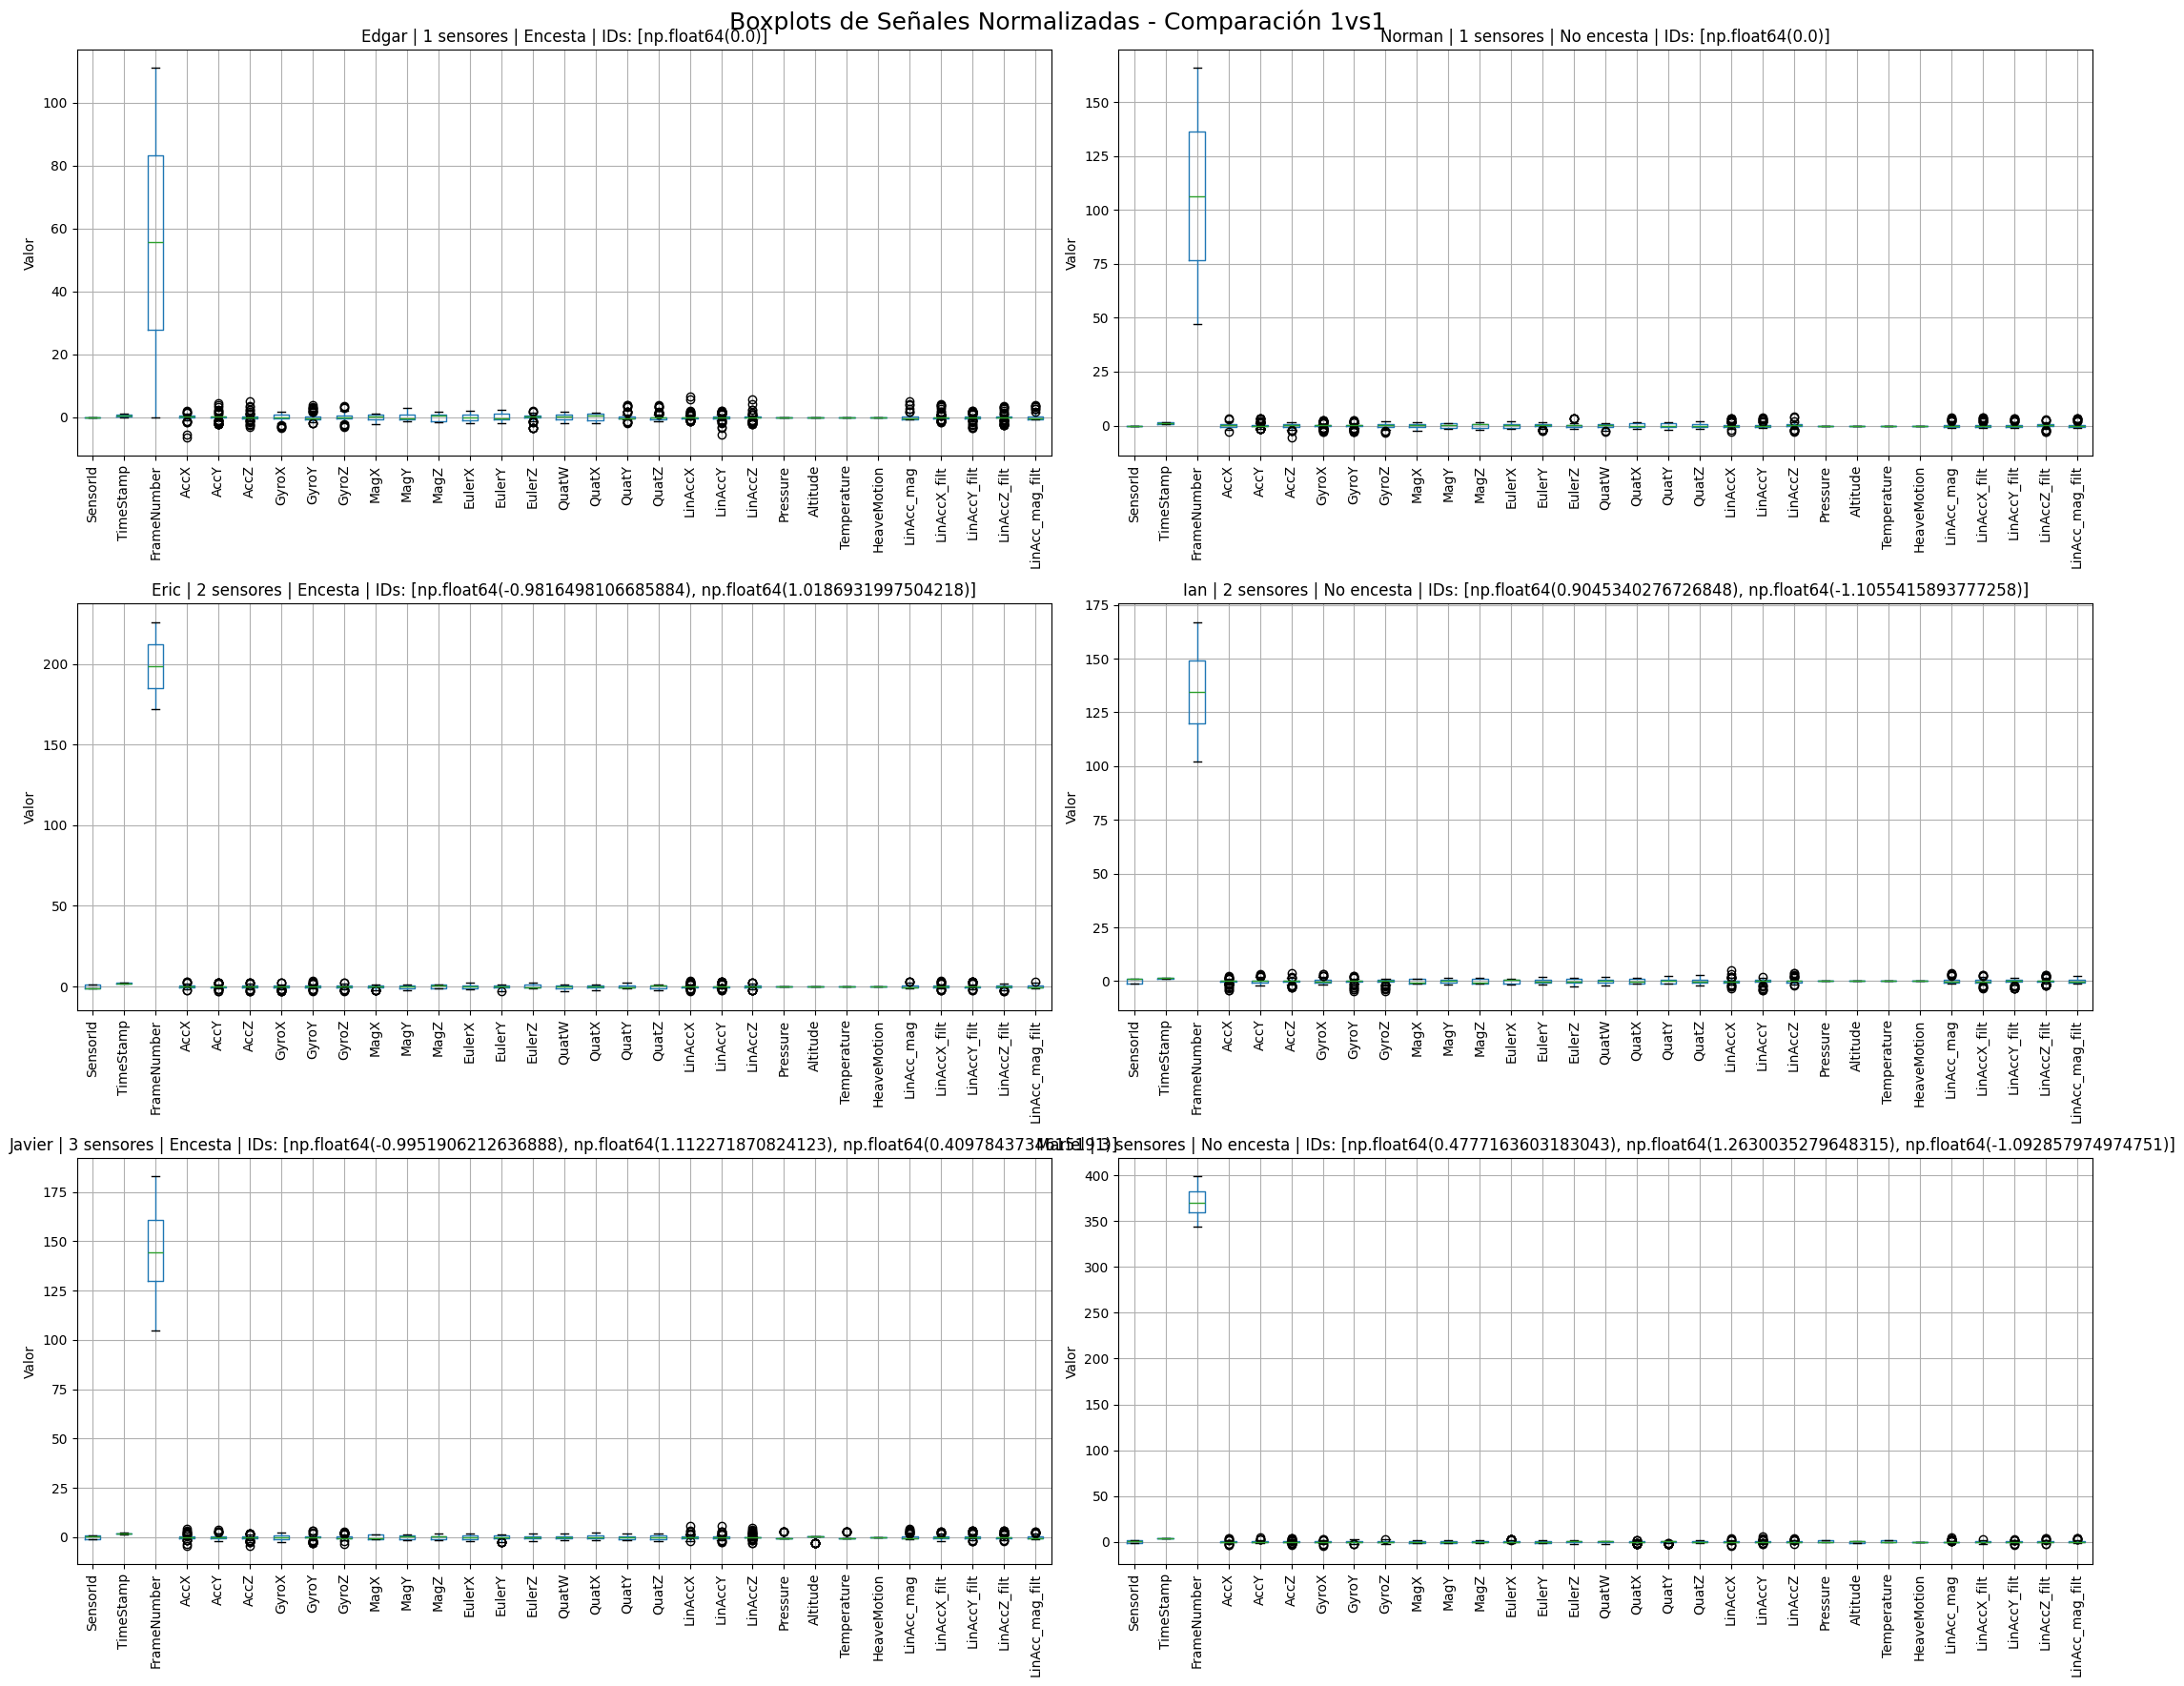

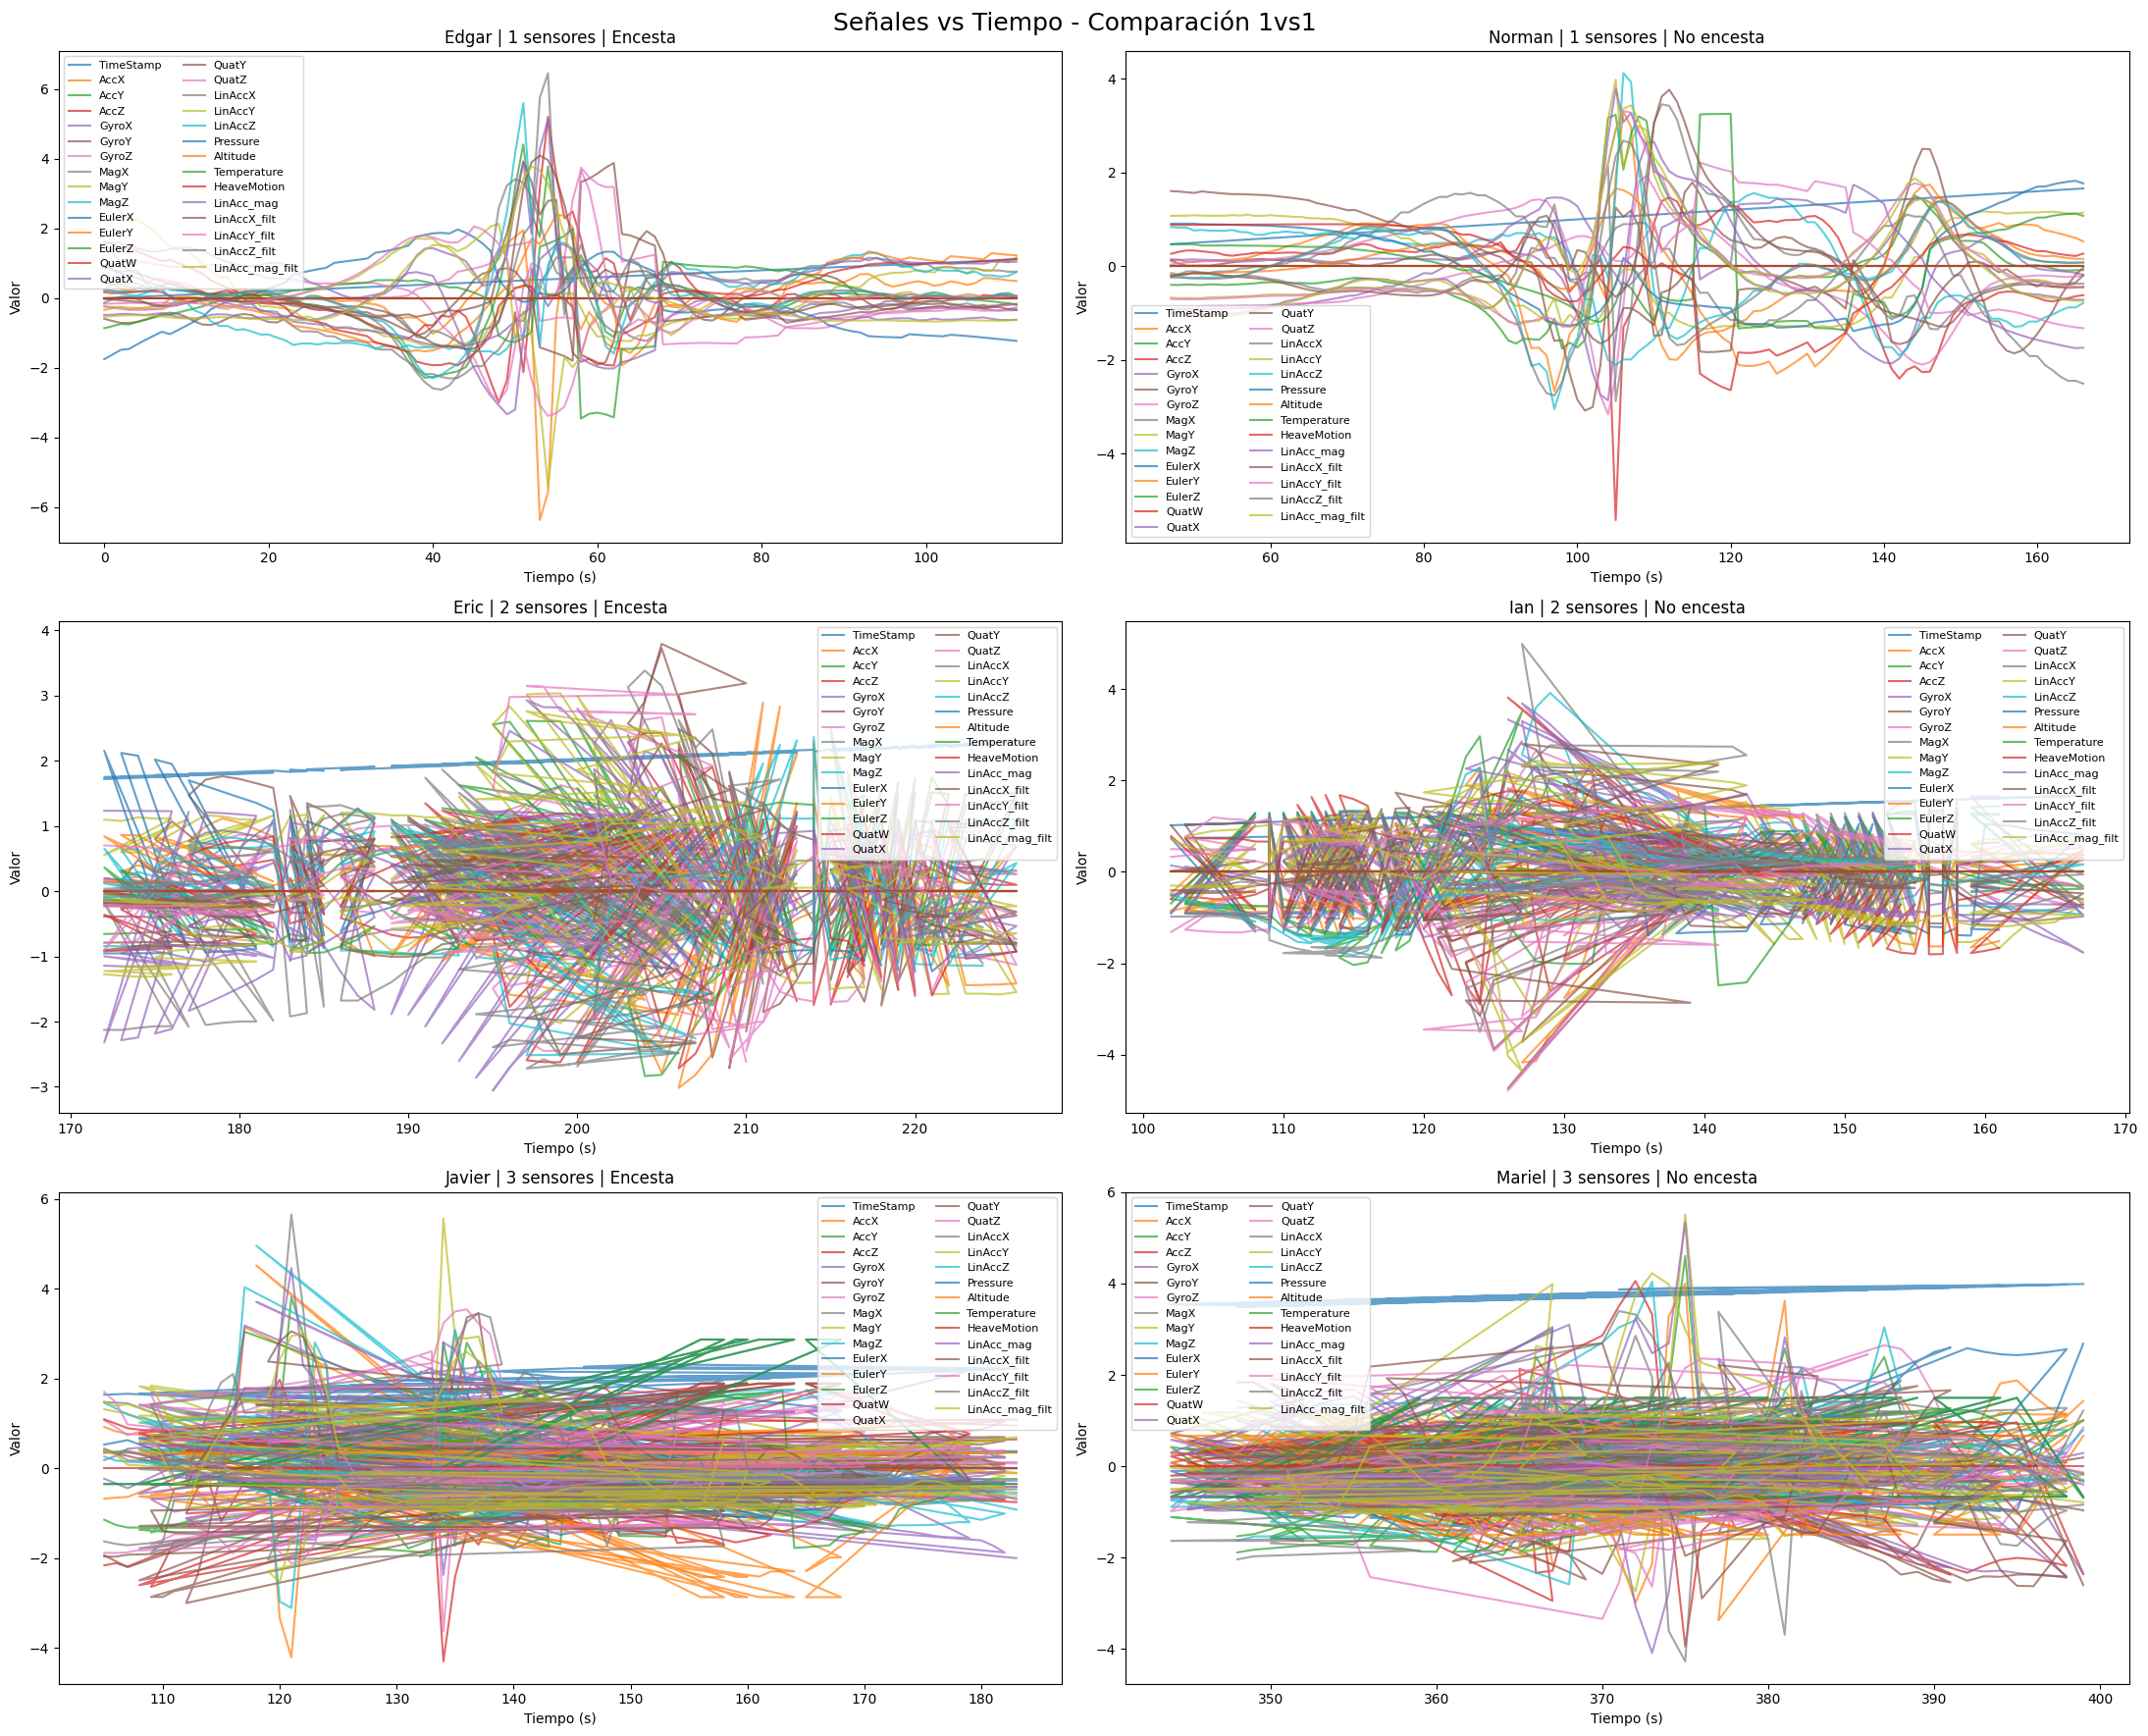

In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. Leer dataset con clases
# ==============================
data_info = pd.read_csv(data_csv_path)

# ==============================
# 2. Contar sensores por tiro e identificar IDs
# ==============================
rows = []
for _, row in data_info.iterrows():
    file_path = os.path.join(data_clean, row["name_file"])  # usar preprocesados
    sensores = set()

    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path)
        df_temp.columns = df_temp.columns.str.strip()
        if "SensorId" in df_temp.columns:
            sensores.update(df_temp["SensorId"].dropna().unique())

    rows.append({
        "student": row["student"],
        "try": row["try"],
        "class": 1 if row["class"] > 0 else 0,
        "name_file": row["name_file"],
        "cantidad_sensores": len(sensores),
        "sensor_ids": list(sensores)
    })

try_df = pd.DataFrame(rows)

# Agrupar por tiro único
try_unique = (
    try_df
    .groupby(["student", "try"])
    .agg({
        "class": "first",
        "name_file": "first",
        "cantidad_sensores": "max",
        "sensor_ids": "first"
    })
    .reset_index()
)

# ==============================
# 3. Seleccionar 6 tiros: 1 vs 1 por sensores
# ==============================
selected = []
used_students = set()

for sensors in [1, 2, 3]:
    # Encesta
    enceste = try_unique[
        (try_unique["cantidad_sensores"] == sensors) &
        (try_unique["class"] == 1) &
        (~try_unique["student"].isin(used_students))
    ]
    if not enceste.empty:
        selected.append(enceste.iloc[0])
        used_students.add(enceste.iloc[0]["student"])

    # Fallo
    fallo = try_unique[
        (try_unique["cantidad_sensores"] == sensors) &
        (try_unique["class"] == 0) &
        (~try_unique["student"].isin(used_students))
    ]
    if not fallo.empty:
        selected.append(fallo.iloc[0])
        used_students.add(fallo.iloc[0]["student"])

# ==============================
# 4. Mostrar información de los seleccionados
# ==============================
selected_df = pd.DataFrame(selected)
display(selected_df[["student", "cantidad_sensores", "class", "name_file", "sensor_ids"]])

# ==============================
# 5. Graficar grid 3x2 boxplots
# ==============================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    file_path = os.path.join(data_clean, row["name_file"])  # usar preprocesado
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    numeric_df = df.select_dtypes(include=[np.number])

    numeric_df.boxplot(ax=ax, rot=90)

    ax.set_title(
        f'{row["student"]} | {row["cantidad_sensores"]} sensores | '
        f'{"Encesta" if row["class"]==1 else "No encesta"} | IDs: {row["sensor_ids"]}'
    )
    ax.set_ylabel("Valor")

# Apagar ejes sobrantes si faltan
for i in range(len(selected), len(axes)):
    axes[i].axis("off")

plt.suptitle("Boxplots de Señales Normalizadas - Comparación 1vs1", fontsize=18)
plt.tight_layout()
plt.show()

# ==============================
# 6. Graficar señales vs tiempo
# ==============================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    file_path = os.path.join(data_clean, row["name_file"])  # usar preprocesado
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # Seleccionar tiempo
    if "TimeStamp (s)" in df.columns:
        time = df["TimeStamp (s)"]
    else:
        time = df["FrameNumber"]  # fallback

    numeric_df = df.select_dtypes(include=[np.number]).copy()

    # Quitar columnas que no son señales
    for col in ["TimeStamp (s)", "FrameNumber", "SensorId"]:
        if col in numeric_df.columns:
            numeric_df = numeric_df.drop(columns=[col])

    # Graficar cada señal vs tiempo
    for col in numeric_df.columns:
        ax.plot(time, numeric_df[col], alpha=0.7, label=col)

    ax.set_title(
        f'{row["student"]} | {row["cantidad_sensores"]} sensores | '
        f'{"Encesta" if row["class"]==1 else "No encesta"}'
    )
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Valor")
    ax.legend(fontsize=8, ncol=2)

# Apagar ejes sobrantes si faltan
for i in range(len(selected), len(axes)):
    axes[i].axis("off")

plt.suptitle("Señales vs Tiempo - Comparación 1vs1", fontsize=18)
plt.tight_layout()
plt.show()

---

# 03 Extracción de características

    Cálculo de features estadísticos, temporales y espectrales para las señales seleccionadas.

    Integración de características de alto nivel, como orientación en cuaterniones o ángulos de Euler.

## Extracción de Features Temporales con TSFEL

Este módulo transforma señales inerciales **ya segmentadas por evento (~1 segundo)** en un dataset estructurado de características estadísticas usando micro-ventanas temporales.

---

### Definición Formal

Sea una señal discreta:

$$
x(t), \quad t = 1,2,\dots,N
$$

En lugar de calcular estadísticas sobre toda la señal del evento, se divide en ventanas cortas:

$$
W_k = \{x(t_k), x(t_k+1), \dots, x(t_k + L -1)\}
$$

donde:

- $L$ = tamaño de ventana en muestras  
- $t_k = k \cdot L \cdot (1 - overlap)$  

Cada ventana produce un vector de características:

$$
\mathbf{f}_k = [f_1(W_k), f_2(W_k), \dots, f_m(W_k)]
$$

---

### Frecuencia de muestreo

$$
f_s = 100 \text{ Hz}
$$

---

### Tamaño de Ventana

Se utilizó:

$$
T = 0.2 \text{ segundos}
$$

Entonces:

$$
L = f_s \cdot T = 100 \cdot 0.2 = 20 \text{ muestras}
$$

Cada ventana contiene 20 muestras consecutivas.

Dado que el evento completo dura aproximadamente 1 segundo (60–120 muestras):

- Cada archivo se divide en múltiples segmentos de 0.2 s.
- Se mantiene estabilidad para features espectrales.
- Se captura micro-dinámica interna del evento.

---

### Overlap

Se utilizó:

$$
overlap = 0.5
$$

El desplazamiento entre ventanas es:

$$
L \cdot (1 - 0.5) = 20 \cdot 0.5 = 10
$$

Cada nueva ventana comienza 10 muestras después de la anterior.


---


In [60]:
import os
import pandas as pd
import tsfel
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

In [43]:
! pip install tsfel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.0 MB/s eta 0:00:00


In [82]:
import os
import pandas as pd
import tsfel
from tqdm import tqdm


def extract_tsfel_per_file_recursive(input_path: str,
                                     output_path: str,
                                     fs: int = 100,
                                     window_seconds: float = 1.0,
                                     overlap: float = 0.5,
                                     domain: str = "all"):

    os.makedirs(output_path, exist_ok=True)

    cfg = tsfel.get_features_by_domain(domain)
    window_size = int(fs * window_seconds)

    all_csv_files = []
    for root, _, files in os.walk(input_path):
        for file in files:
            if file.endswith(".csv"):
                all_csv_files.append(os.path.join(root, file))

    for file_path in tqdm(all_csv_files):

        try:
            df = pd.read_csv(file_path)

            exclude_cols = ["SensorId", "TimeStamp", "FrameNumber"]
            df = df.drop(columns=[c for c in exclude_cols if c in df.columns])

            df_numeric = df.select_dtypes(include=["float64", "int64"])
            if df_numeric.shape[1] == 0:
                continue

            features = tsfel.time_series_features_extractor(
                cfg,
                df_numeric,
                fs=fs,
                window_size=window_size,
                overlap=overlap,
                verbose=0
            )

            original_name = os.path.basename(file_path)
            save_path = os.path.join(output_path, original_name)

            features.to_csv(save_path, index=False)

        except Exception as e:
            print(f"Error en {file_path}: {e}")

    print("Total archivos procesados:", len(all_csv_files))
    print("Todos guardados en:", output_path)

In [83]:
import os
import pandas as pd
import numpy as np

data_clean = "/content/drive/MyDrive/data_clean"

lengths = []

for file in sorted(os.listdir(data_clean)):
    if not file.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(data_clean, file))
    n = len(df)
    lengths.append(n)

lengths = np.array(lengths)

print("Número de archivos:", len(lengths))
print("Muestras por archivo (primeros 10):", lengths[:10])
print("Mínimo:", lengths.min())
print("Máximo:", lengths.max())
print("Mediana:", np.median(lengths))
print("Media:", np.mean(lengths))
print("Percentiles:", np.percentile(lengths, [10,25,50,75,90]))

Número de archivos: 111
Muestras por archivo (primeros 10): [116 103  60 100  60  95 112  92 120  60]
Mínimo: 60
Máximo: 120
Mediana: 120.0
Media: 113.81981981981981
Percentiles: [ 92.  119.5 120.  120.  120. ]


In [95]:
features_path = "/content/drive/MyDrive/features_dataset"
os.makedirs(features_path, exist_ok=True)

In [88]:

extract_tsfel_per_file_recursive(
    input_path=clean_path,
    output_path=features_path,
    fs=100,
    window_seconds=0.2,
    overlap=0.5,
    domain="all"
)

  0%|          | 0/111 [00:00<?, ?it/s]

  1%|          | 1/111 [00:18<34:23, 18.76s/it]

  2%|▏         | 2/111 [00:29<25:18, 13.93s/it]

  3%|▎         | 3/111 [00:37<20:14, 11.25s/it]

  4%|▎         | 4/111 [00:48<19:38, 11.01s/it]

...

 97%|█████████▋| 108/111 [17:56<00:26,  8.94s/it]

 98%|█████████▊| 109/111 [18:07<00:19,  9.54s/it]

 99%|█████████▉| 110/111 [18:15<00:08,  8.92s/it]

100%|██████████| 111/111 [18:25<00:00,  9.96s/it]

Total archivos procesados: 111
Todos guardados en: /content/drive/MyDrive/features_dataset


In [96]:
import os
import pandas as pd
import numpy as np

files = [f for f in os.listdir(features_path) if f.endswith(".csv")]
files = sorted(files)

num_columns = []
num_rows = []

for file in files:
    df = pd.read_csv(os.path.join(features_path, file))
    num_columns.append(df.shape[1])
    num_rows.append(df.shape[0])

num_columns = np.array(num_columns)
num_rows = np.array(num_rows)

print("Número de archivos:", len(files))
print("Columnas (primer archivo):", num_columns[0])
print("Columnas mínimas:", num_columns.min())
print("Columnas máximas:", num_columns.max())
print("Columnas promedio:", num_columns.mean())
print("Filas promedio por archivo:", num_rows.mean())

Número de archivos: 111
Columnas (primer archivo): 3948
Columnas mínimas: 3948
Columnas máximas: 3948
Columnas promedio: 3948.0
Filas promedio por archivo: 10.27027027027027



### Resultados

- Número total de archivos: **111**
- Número de columnas (features) por archivo: **3948**
- Consistencia dimensional:
  - Mínimo: 3948
  - Máximo: 3948
  - Promedio: 3948
- Filas promedio por archivo: **≈ 10.27**

---


### Consistencia estructural

Todos los archivos tienen exactamente **3948 columnas**, lo que indica que:

- La extracción de features fue consistente.
- No hubo errores de dominio o ventanas incompletas.
- La dimensionalidad es fija para todos los eventos.

Esto es crítico para modelos supervisados.

---

### Alta dimensionalidad

Cada ventana genera un vector en:

$$
\mathbb{R}^{3948}
$$

Es un espacio de muy alta dimensión.

Implicaciones:

- Riesgo elevado de overfitting en modelos como MLP.
- Redundancia significativa entre features.
- Correlaciones fuertes entre variables espectrales y estadísticas.

---

### Estructura temporal

Cada archivo tiene en promedio ~10 ventanas:

- 1 evento → ~10 vectores de 3948 dimensiones.
- Total aproximado de muestras para entrenamiento:

$$
111 \times 10.27 \approx 1140 \text{ instancias}
$$

Por lo tanto:

- ~1140 muestras
- 3948 features

Esto implica:

$$
\text{features} \gg \text{samples}
$$

Escenario típico donde PCA es recomendable.

---

Aplicar PCA antes de entrenar para:

- Reducir dimensionalidad
- Eliminar colinealidad
- Mejorar estabilidad numérica
- Reducir riesgo de sobreajuste

---

# 04 Evaluación interna

    Entrenamiento de 5 modelos de predicción bajo un esquema de validación cruzada estratificada.

    Reporte del desempeño mediante el F1-Score y análisis de la matriz de confusión del mejor clasificador.


In [ ]:
# =========================
# Librerías
# =========================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


In [ ]:
# =========================
# Carga de datos
# =========================
def load_data(features_path, labels_path):
    labels_df = pd.read_csv(labels_path)
    X_list, y_list = [], []

    all_columns = set()
    for file in os.listdir(features_path):
        if file.endswith(".csv") and file in labels_df["name_file"].values:
            df = pd.read_csv(os.path.join(features_path, file))
            all_columns.update(df.columns)

    all_columns = sorted(list(all_columns))

    for file in os.listdir(features_path):
        if file.endswith(".csv") and file in labels_df["name_file"].values:
            df = pd.read_csv(os.path.join(features_path, file))
            df = df.reindex(columns=all_columns, fill_value=0)
            label = labels_df.loc[
                labels_df["name_file"] == file, "class"
            ].values[0]

            X_list.append(df.values)
            y_list.extend([label] * df.shape[0])

    X = np.vstack(X_list)
    y = np.array(y_list)

    X = np.nan_to_num(X)

    print("Total muestras:", X.shape[0])
    print("Total features:", X.shape[1])

    return X, y

## ¿Qué hace PCA?

PCA transforma las 3948 variables originales en un nuevo conjunto de variables no correlacionadas llamadas **componentes principales**, que son combinaciones lineales de las variables originales.

### Matemáticamente

1. Estandarización:

$$
X_{scaled} = \frac{X - \mu}{\sigma}
$$

2. Matriz de covarianza:

$$
\Sigma = \frac{1}{n-1} X^T X
$$

3. Descomposición espectral:

$$
\Sigma v_i = \lambda_i v_i
$$

4. Proyección al nuevo espacio:

$$
Z = X V_k
$$

donde \(V_k\) contiene los autovectores asociados a los mayores autovalores.

---

### En este experimento

- 3948 → ~395 componentes  
- Varianza explicada ≈ 95%

$$
\frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i} \approx 0.95
$$

Resultado: reducción de dimensionalidad conservando la mayor parte de la estructura informativa del dataset.

In [ ]:
# =========================
# PCA
# =========================
def apply_pca(X_train, X_test, variance=0.95):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pca = PCA(n_components=variance, random_state=SEED)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    print("Dimensión tras PCA:", X_train.shape[1])
    print("Varianza explicada:", pca.explained_variance_ratio_.sum())

    return X_train, X_test

### SMOTE (Synthetic Minority Over-sampling Technique)
Genera muestras sintéticas de la clase minoritaria interpolando entre vecinos cercanos.
Aumenta artificialmente la cantidad de ejemplos minoritarios.

### Random UnderSampling
Elimina aleatoriamente muestras de la clase mayoritaria.
Reduce el tamaño de la clase dominante para equilibrar proporciones.

### SMOTEENN
Combina SMOTE + Edited Nearest Neighbors.

Genera muestras sintéticas (SMOTE).

Elimina ejemplos ruidosos o mal clasificados mediante vecinos (ENN).
Balancea y limpia simultáneamente.

In [ ]:
# =========================
# Modelos + Balanceo correcto
# =========================
def run_models(X_train, y_train):

    balancing = {
        "SMOTE": SMOTE(random_state=SEED),
        "Under": RandomUnderSampler(random_state=SEED),
        "SMOTEENN": SMOTEENN(random_state=SEED)
    }

    models = {
        "KNN": (KNeighborsClassifier(), {"model__n_neighbors": [3,5,7]}),
        "SVM": (SVC(), {"model__C": [0.1,1,10], "model__kernel": ["rbf","linear"]}),
        "XGB": (XGBClassifier(eval_metric="logloss", random_state=SEED),
                {"model__n_estimators": [100,200],
                 "model__max_depth": [3,5]}),
        "MLP": (MLPClassifier(max_iter=500, random_state=SEED),
                {"model__hidden_layer_sizes": [(100,), (100,50)]})
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    results = []
    best_score = 0
    best_model = None

    for bal_name, sampler in balancing.items():
        for model_name, (model, grid_params) in models.items():

            pipe = Pipeline([
                ("sampler", sampler),
                ("model", model)
            ])

            grid = GridSearchCV(
                pipe,
                grid_params,
                scoring="f1_macro",
                cv=skf,
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            score = grid.best_score_

            results.append({
                "Balance": bal_name,
                "Model": model_name,
                "F1_macro": score,
                "BestParams": grid.best_params_
            })

            if score > best_score:
                best_score = score
                best_model = grid.best_estimator_

    results_df = pd.DataFrame(results).sort_values(
        by="F1_macro",
        ascending=False
    )

    print("\nRESULTADOS COMPLETOS")
    print(results_df)

    return best_model, results_df

In [ ]:
# =========================
# Matriz de confusión
# =========================
def plot_confusion(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fallo", "Enceste"],
        yticklabels=["Fallo", "Enceste"]
    )
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()


Total muestras: 1140
Total features: 3948
Dimensión tras PCA: 395
Varianza explicada: 0.9501460647641191

RESULTADOS COMPLETOS
     Balance Model  F1_macro  \
3      SMOTE   MLP  0.619324   
1      SMOTE   SVM  0.587044   
2      SMOTE   XGB  0.548931   
5      Under   SVM  0.538207   
4      Under   KNN  0.524877   
7      Under   MLP  0.519329   
6      Under   XGB  0.490039   
11  SMOTEENN   MLP  0.429360   
0      SMOTE   KNN  0.425465   
9   SMOTEENN   SVM  0.421012   
10  SMOTEENN   XGB  0.319181   
8   SMOTEENN   KNN  0.315650   

                                           BestParams  
3            {'model__hidden_layer_sizes': (100, 50)}  
1        {'model__C': 0.1, 'model__kernel': 'linear'}  
2   {'model__max_depth': 3, 'model__n_estimators':...  
5             {'model__C': 1, 'model__kernel': 'rbf'}  
4                           {'model__n_neighbors': 5}  
7               {'model__hidden_layer_sizes': (100,)}  
6   {'model__max_depth': 3, 'model__n_estimators':...  
11      

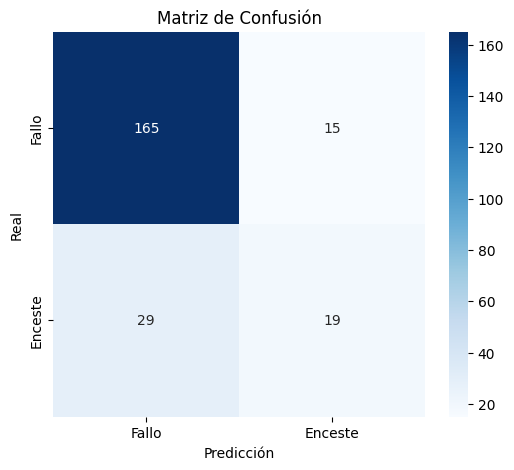

In [1]:
if __name__ == "__main__":

    #train
    features_path = "/content/drive/MyDrive/features_dataset"
    labels_path = "/content/drive/MyDrive/Inercial/data.csv"

    X, y = load_data(features_path, labels_path)

    # Split HOLD-OUT (test jamás se ve)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=SEED
    )

    # PCA SOLO con train
    X_train, X_test = apply_pca(X_train, X_test)

    # GridSearch + balance SOLO en train
    best_model, results_df = run_models(X_train, y_train)

    # Evaluación final en TEST
    y_pred = best_model.predict(X_test)

    print("\nF1 TEST:", f1_score(y_test, y_pred, average="macro"))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Matriz bonita azul
    plot_confusion(y_test, y_pred)

## Validación interna

Se realizó validación cruzada estratificada (5-fold) sobre:

- 1140 muestras  
- 3948 features originales  
- 395 componentes tras PCA  
- 95.01% de varianza explicada  

Se compararon tres técnicas de balanceo:

- SMOTE  
- Random UnderSampling  
- SMOTEENN  

Modelos evaluados:

- KNN  
- SVM  
- XGBoost  
- MLP  

Métrica utilizada: **F1-macro**, adecuada para clases desbalanceadas.

---

## Resultados

El mejor desempeño en validación cruzada fue:

- Balanceo: **SMOTE**
- Modelo: **MLP**
- F1-macro (CV): **0.6193**

En el conjunto de test interno:

- F1-macro: **0.6729**
- Accuracy: 0.81  

La clase minoritaria (1) muestra menor recall (0.40), indicando que aún existe dificultad en la generalización hacia dicha clase pese al balanceo.

---

## Conclusión

SMOTE + MLP ofrece el mejor compromiso entre sensibilidad y estabilidad en este espacio reducido por PCA.  
La reducción a 395 componentes mantiene alta varianza explicada y mejora la estabilidad del entrenamiento bajo alta dimensionalidad.

In [13]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [14]:
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")
model = joblib.load("model.pkl")

# 05 Validación externa

    Exportación del mejor modelo y preparación de funciones de preprocesamiento de los datos crudos.

    Implementación de un pipeline de inferencia en el Notebook para nuevos datos siguiendo instrucciones técnicas precisas.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

Despúes de ejecutar el entrenamiento, aquí se ajustan los paths, data_test es la carpeta de validación externa y clean_test será la nueva carpeta donde se aplica el mismo preprocesamiento.

In [91]:
data_test = "/content/drive/MyDrive/Inercial/test"
clean_test = "/content/drive/MyDrive/test_clean"

preprocess_dataset(
    data_path=data_test,
    clean_path=clean_test
)

 70%|███████   | 21/30 [00:08<00:04,  2.05it/s]

Error en Tony_01.csv: unsupported operand type(s) for ** or pow(): 'str' and 'int'


 73%|███████▎  | 22/30 [00:08<00:03,  2.30it/s]

Error en Tony_02.csv: unsupported operand type(s) for ** or pow(): 'str' and 'int'


 80%|████████  | 24/30 [00:09<00:02,  2.71it/s]

Error en Tony_04.csv: unsupported operand type(s) for ** or pow(): 'str' and 'int'


 87%|████████▋ | 26/30 [00:09<00:01,  2.89it/s]

Error en Tony_06.csv: unsupported operand type(s) for ** or pow(): 'str' and 'int'


100%|██████████| 30/30 [00:11<00:00,  2.64it/s]

Error en Tony_10.csv: unsupported operand type(s) for ** or pow(): 'str' and 'int'
Preprocesamiento completado. Archivos guardados en: /content/drive/MyDrive/test_clean


Posteriormente, se creará una nueva carpeta TEST donde se utilizará el mismo proceso de extracción de características apartir de la carpeta generada en el paso anterior test_clean.

In [92]:
output_path="/content/drive/MyDrive/TEST"
clean_test = "/content/drive/MyDrive/test_clean"
os.makedirs(output_path, exist_ok=True)
os.makedirs(clean_test, exist_ok=True)

extract_tsfel_per_file_recursive(
    input_path=clean_test,
    output_path=output_path,
    fs=100,
    window_seconds=0.2,
    overlap=0.5,
    domain="all"
)

  0%|          | 0/25 [00:00<?, ?it/s]

  4%|▍         | 1/25 [00:06<02:32,  6.36s/it]

  8%|▊         | 2/25 [00:16<03:23,  8.86s/it]

 12%|█▏        | 3/25 [00:25<03:11,  8.73s/it]

 16%|█▌        | 4/25 [00:35<03:13,  9.23s/it]

...

 88%|████████▊ | 22/25 [03:31<00:26,  8.84s/it]

 92%|█████████▏| 23/25 [03:39<00:16,  8.39s/it]

 96%|█████████▌| 24/25 [03:49<00:09,  9.00s/it]

100%|██████████| 25/25 [03:57<00:00,  9.48s/it]

Total archivos procesados: 25
Todos guardados en: /content/drive/MyDrive/TEST


Se establece el path de las features nuevamente

In [6]:
external_features_path = "/content/drive/MyDrive/TEST"

In [ ]:
Ahora se usa la misma configuración guardada en memoria durante el entrenamiento

In [9]:
# Volvemos al split ORIGINAL
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

In [7]:
def load_external_data(features_path, reference_columns):

    X_list = []

    for file in os.listdir(features_path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(features_path, file))
            df = df.reindex(columns=reference_columns, fill_value=0)
            X_list.append(df.values)

    X_ext = np.vstack(X_list)
    X_ext = np.nan_to_num(X_ext)

    print("Muestras externas:", X_ext.shape)

    return X_ext

In [10]:
# Scaler correcto
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# PCA correcto
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)  # debe dar (912, 395)

(912, 395)


In [11]:
X_external_scaled = scaler.transform(X_external)
X_external_pca = pca.transform(X_external_scaled)

print(X_external_pca.shape)  # debe dar (n_muestras, 395)

(253, 395)


In [12]:
y_external_pred = best_model.predict(X_external_pca)

In [15]:
def predict_by_file(features_path, scaler, pca, model, reference_columns):

    results = []

    for file in os.listdir(features_path):

        if file.endswith(".csv"):

            # Cargar CSV
            df = pd.read_csv(os.path.join(features_path, file))

            # Alinear columnas
            df = df.reindex(columns=reference_columns, fill_value=0)

            X_file = df.values
            X_file = np.nan_to_num(X_file)

            # Transformaciones EXACTAS de entrenamiento
            X_scaled = scaler.transform(X_file)
            X_pca = pca.transform(X_scaled)

            # Probabilidades por ventana
            probs = model.predict_proba(X_pca)[:, 1]

            # Promedio de probabilidad del archivo completo
            mean_prob = np.mean(probs)

            # Decisión final
            final_pred = int(mean_prob >= 0.5)

            results.append({
                "file_name": file,
                "mean_probability": mean_prob,
                "prediction": final_pred
            })

    return pd.DataFrame(results)

In [17]:
def get_reference_columns(features_path, labels_path):

    labels_df = pd.read_csv(labels_path)
    all_columns = set()

    for file in os.listdir(features_path):
        if file.endswith(".csv") and file in labels_df["name_file"].values:
            df = pd.read_csv(os.path.join(features_path, file))
            all_columns.update(df.columns)

    return sorted(list(all_columns))

In [18]:
reference_columns = get_reference_columns(
    "/content/drive/MyDrive/features_dataset",
    "/content/drive/MyDrive/Inercial/data.csv"
)

print("Total columnas:", len(reference_columns))

Total columnas: 3948


In [20]:
df_results = predict_by_file(
    external_features_path,
    scaler,
    pca,
    best_model,
    reference_columns
)

print(df_results)

      file_name  mean_probability  prediction
0   Joan_01.csv          0.317598           0
1   Joan_02.csv          0.402866           0
2   Joan_03.csv          0.411093           0
3   Joan_04.csv          0.270899           0
4   Joan_05.csv          0.572336           1
5   Joan_06.csv          0.444307           0
6   Joan_07.csv          0.289363           0
7   Joan_08.csv          0.245437           0
8   Joan_09.csv          0.112950           0
9   Joan_10.csv          0.418689           0
10  Joan_11.csv          0.724632           1
11  Joan_12.csv          0.313600           0
12  Joan_13.csv          0.431275           0
13  Joan_14.csv          0.181149           0
14  Joan_15.csv          0.290767           0
15  Joan_16.csv          0.339348           0
16  Joan_17.csv          0.329054           0
17  Joan_18.csv          0.132835           0
18  Joan_19.csv          0.160725           0
19  Joan_20.csv          0.048311           0
20  Tony_03.csv          0.090881 

## Validación externa

Se evaluó el modelo entrenado (SMOTE + MLP) sobre sujetos no vistos durante la validación interna.

### Distribución real

- Total muestras: 25  
- Clase 1 real: 1 caso (`Joan_01.csv`)  
- Clase 0 real: 24 casos  

### Predicciones relevantes

El modelo predijo clase 1 en:

- `Joan_05.csv`
- `Joan_11.csv`

El único positivo real (`Joan_01.csv`) fue clasificado como 0.

---

## Métricas externas

Matriz de confusión:

- TP = 0  
- FP = 2  
- TN = 22  
- FN = 1  

F1-macro ≈ 0.47  
Accuracy ≈ 0.88  

---

## Interpretación

- El modelo no detectó el único positivo real (recall clase 1 = 0).
- Generó dos falsos positivos.
- La accuracy es alta debido al fuerte desbalance.
- El desempeño en generalización externa cae respecto al test interno.

Esto indica que el modelo está sobreajustado al patrón de entrenamiento y no captura de forma robusta la estructura de la clase minoritaria en sujetos nuevos.